# Exploratory Data Analysis (EDA) — Traffic + Meteo Dataset

Performs an EDA on the unified `traffic-meteo.csv` dataset generated in `2-unified-data-processing.ipynb`.

**Target variable**: `intensidad` (hourly traffic intensity per sensor).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

TITLE_PAD = 14  # distance between title and plot top edge (default matplotlib = 6)

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  14,
    'figure.titlesize': 16,
    'axes.titlepad':    TITLE_PAD,
})

# Boosted sizes for multi-subplot figures (2+ panels per row)
MULTI_RC = {
    'axes.titlesize':   21,
    'axes.labelsize':   19,
    'xtick.labelsize':  17,
    'ytick.labelsize':  17,
    'legend.fontsize':  19,
    'axes.titlepad':    TITLE_PAD,
}

## 1. Load dataset

In [2]:
df = pd.read_csv('dataset/processed/traffic-meteo-14-slice.csv', parse_dates=['fecha'])
print(f'Shape: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Shape: 3,597,048 rows, 35 columns


,fecha,dia_semana,hora_dia,mes,festivo,vispera_festivo,id,tipo_elem,intensidad,ocupacion,vmed,periodo_integracion,n_validos_15m,n_error_E,n_error_S,n_error_NaN,error,hora_incompleta,hora_baja_confianza,intensidad_is_imputed,ocupacion_is_imputed,vmed_is_imputed,peso_loss,prcp,temp,coco,wspd,cldc,forecast_temp,forecast_prec,latitud,longitud,distrito,angle_sin,angle_cos
0,2024-12-29 00:00:00,6,0,12,0,0,1006,C30,627.0,2.00,66.50,20.0,4,0,0,0,N,0,0,False,False,False,1.0,0.0,2.8,1,7.2,0,2.5,0.0,40.411894,-3.736324,10.0,-0.128502,-0.991709
1,2024-12-29 01:00:00,6,1,12,0,0,1006,C30,570.0,1.75,68.00,20.0,4,0,0,0,N,0,0,False,False,False,1.0,0.0,2.3,1,7.2,0,1.9,0.0,40.411894,-3.736324,10.0,-0.128502,-0.991709
2,2024-12-29 02:00:00,6,2,12,0,0,1006,C30,411.0,1.50,66.50,20.0,4,0,0,0,N,0,0,False,False,False,1.0,0.0,1.7,1,7.2,0,1.7,0.0,40.411894,-3.736324,10.0,-0.128502,-0.991709
3,2024-12-29 03:00:00,6,3,12,0,0,1006,C30,348.0,1.00,65.75,20.0,4,0,0,0,N,0,0,False,False,False,1.0,0.0,1.3,1,6.5,0,1.4,0.0,40.411894,-3.736324,10.0,-0.128502,-0.991709
4,2024-12-29 04:00:00,6,4,12,0,0,1006,C30,282.0,0.75,65.25,20.0,4,0,0,0,N,0,0,False,False,False,1.0,0.0,0.7,1,7.2,0,1.2,0.0,40.411894,-3.736324,10.0,-0.128502,-0.991709


## 2. Basic inspection

In [3]:
df.dtypes

fecha                    datetime64[ns]
dia_semana                        int64
hora_dia                          int64
mes                               int64
festivo                           int64
vispera_festivo                   int64
id                                int64
tipo_elem                        object
intensidad                      float64
ocupacion                       float64
vmed                            float64
periodo_integracion             float64
n_validos_15m                     int64
n_error_E                         int64
n_error_S                         int64
n_error_NaN                       int64
error                            object
hora_incompleta                   int64
hora_baja_confianza               int64
intensidad_is_imputed              bool
ocupacion_is_imputed               bool
vmed_is_imputed                    bool
peso_loss                       float64
prcp                            float64
temp                            float64


In [4]:
# Column classification
CATEGORICAL = ['dia_semana', 'festivo', 'vispera_festivo', 'coco', 'cldc', 'hora_dia', 'mes', 'distrito']
CONTINUOUS = ['intensidad', 'ocupacion', 'vmed', 'prcp', 'temp', 'wspd', 'forecast_temp', 'forecast_prec',
              'latitud', 'longitud', 'angle_sin', 'angle_cos']
META_FLAGS = ['id', 'tipo_elem', 'periodo_integracion', 'n_validos_15m', 'n_error_E', 'n_error_S', 'n_error_NaN',
              'error', 'hora_incompleta', 'hora_baja_confianza',
              'intensidad_is_imputed', 'ocupacion_is_imputed', 'vmed_is_imputed',
              'peso_loss']

print(f'Categorical ({len(CATEGORICAL)}): {CATEGORICAL}')
print(f'Continuous  ({len(CONTINUOUS)}):  {CONTINUOUS}')
print(f'Meta/flags  ({len(META_FLAGS)}): {META_FLAGS}')

Categorical (8): ['dia_semana', 'festivo', 'vispera_festivo', 'coco', 'cldc', 'hora_dia', 'mes', 'distrito']
Continuous  (12):  ['intensidad', 'ocupacion', 'vmed', 'prcp', 'temp', 'wspd', 'forecast_temp', 'forecast_prec', 'latitud', 'longitud', 'angle_sin', 'angle_cos']
Meta/flags  (14): ['id', 'tipo_elem', 'periodo_integracion', 'n_validos_15m', 'n_error_E', 'n_error_S', 'n_error_NaN', 'error', 'hora_incompleta', 'hora_baja_confianza', 'intensidad_is_imputed', 'ocupacion_is_imputed', 'vmed_is_imputed', 'peso_loss']


In [5]:
nulls = df.isnull().sum()
print('Null counts:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values found.')

Null counts:
No null values found.


In [6]:
df[CONTINUOUS].describe()

,intensidad,ocupacion,vmed,prcp,temp,wspd,forecast_temp,forecast_prec,latitud,longitud,angle_sin,angle_cos
count,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06,3.597048e+06
mean,1.196036e+03,6.551114e+00,6.146133e+01,7.220921e-02,1.459865e+01,1.072401e+01,1.481422e+01,7.604411e-02,4.042643e+01,-3.692024e+00,2.719074e-02,-1.485119e-02
std,1.277110e+03,1.178821e+01,2.437676e+01,3.357948e-01,9.608640e+00,5.550664e+00,9.152391e+00,3.276857e-01,3.538343e-02,3.271527e-02,7.460494e-01,6.651696e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.200000e+00,0.000000e+00,-4.500000e+00,0.000000e+00,4.036920e+01,-3.792246e+00,-1.000000e+00,-9.999996e-01
25%,2.213750e+02,1.000000e+00,5.025000e+01,0.000000e+00,7.100000e+00,6.500000e+00,7.900000e+00,0.000000e+00,4.039802e+01,-3.717736e+00,-7.000306e-01,-6.659615e-01
50%,7.292500e+02,3.750000e+00,6.650000e+01,0.000000e+00,1.200000e+01,9.700000e+00,1.250000e+01,0.000000e+00,4.041747e+01,-3.683397e+00,0.000000e+00,6.123234e-17
75%,1.798250e+03,7.750000e+00,7.925000e+01,0.000000e+00,2.180000e+01,1.400000e+01,2.150000e+01,0.000000e+00,4.045447e+01,-3.663496e+00,8.179579e-01,6.045128e-01
max,1.830000e+04,1.000000e+02,1.597500e+02,6.000000e+00,4.020000e+01,4.540000e+01,4.000000e+01,6.400000e+00,4.051561e+01,-3.648389e+00,9.999952e-01,1.000000e+00


In [7]:
for col in CATEGORICAL:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().sort_index())


--- dia_semana ---
dia_semana
0    513864
1    513864
2    513864
3    513864
4    513864
5    513864
6    513864
Name: count, dtype: int64

--- festivo ---
festivo
0    3453840
1     143208
Name: count, dtype: int64

--- vispera_festivo ---
vispera_festivo
0    3470688
1     126360
Name: count, dtype: int64

--- coco ---
coco
1     1260441
2      431379
3     1435239
4        3510
5       93717
7      114426
8      132678
9       77922
12       4563
17      37908
18       4563
19        702
Name: count, dtype: int64

--- cldc ---
cldc
0    1100034
1     301509
2     195156
3     153738
4     136539
5     128466
6     154440
7     247104
8    1180062
Name: count, dtype: int64

--- hora_dia ---
hora_dia
0     149877
1     149877
2     149877
3     149877
4     149877
5     149877
6     149877
7     149877
8     149877
9     149877
10    149877
11    149877
12    149877
13    149877
14    149877
15    149877
16    149877
17    149877
18    149877
19    149877
20    149877
21    149877
2

## 3. Target variable: `intensidad`

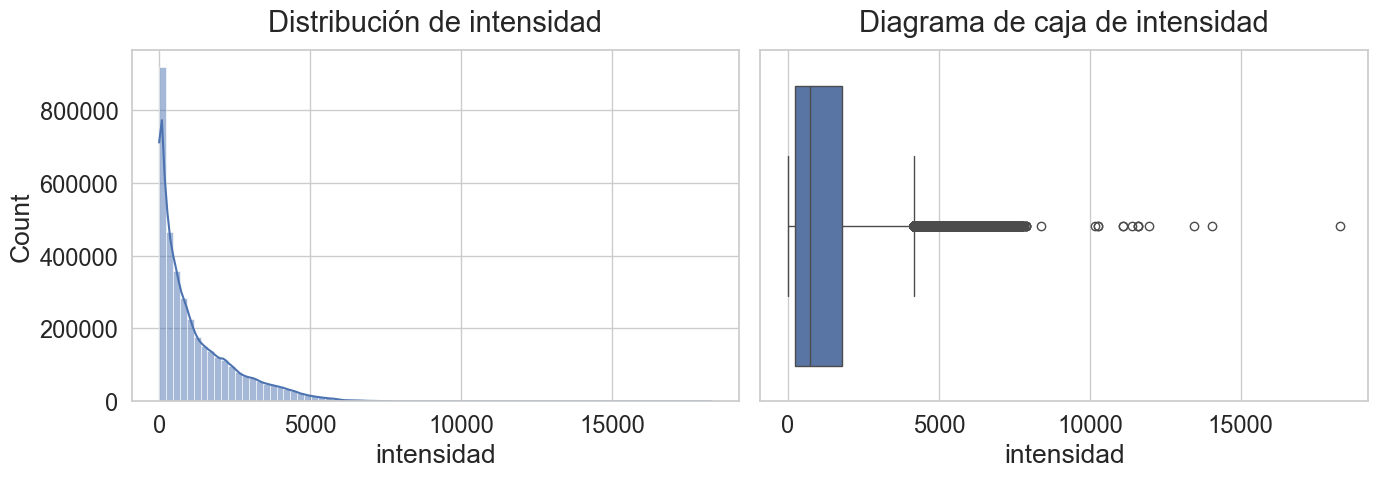

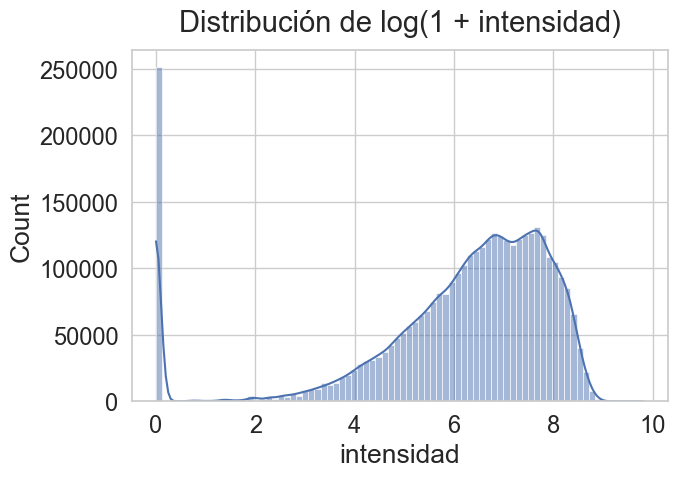

Asimetría (skewness): 1.4359
Curtosis (kurtosis): 1.7232


In [8]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['intensidad'], kde=True, bins=80, ax=axes[0])
    axes[0].set_title('Distribución de intensidad')
    sns.boxplot(x=df['intensidad'], ax=axes[1])
    axes[1].set_title('Diagrama de caja de intensidad')
    plt.tight_layout(); plt.show()

with plt.rc_context(MULTI_RC):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    sns.histplot(np.log1p(df['intensidad']), kde=True, bins=80, ax=ax)
    ax.set_title('Distribución de log(1 + intensidad)')
    plt.tight_layout(); plt.show()

print(f'Asimetría (skewness): {df["intensidad"].skew():.4f}')
print(f'Curtosis (kurtosis): {df["intensidad"].kurt():.4f}')

## 4. Distribution of continuous variables

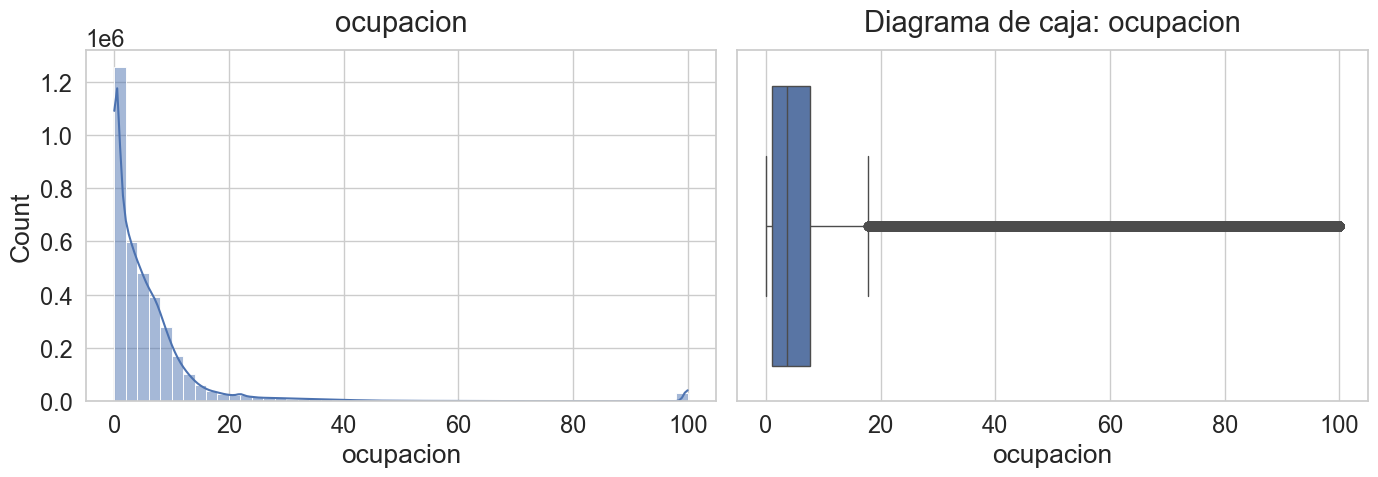

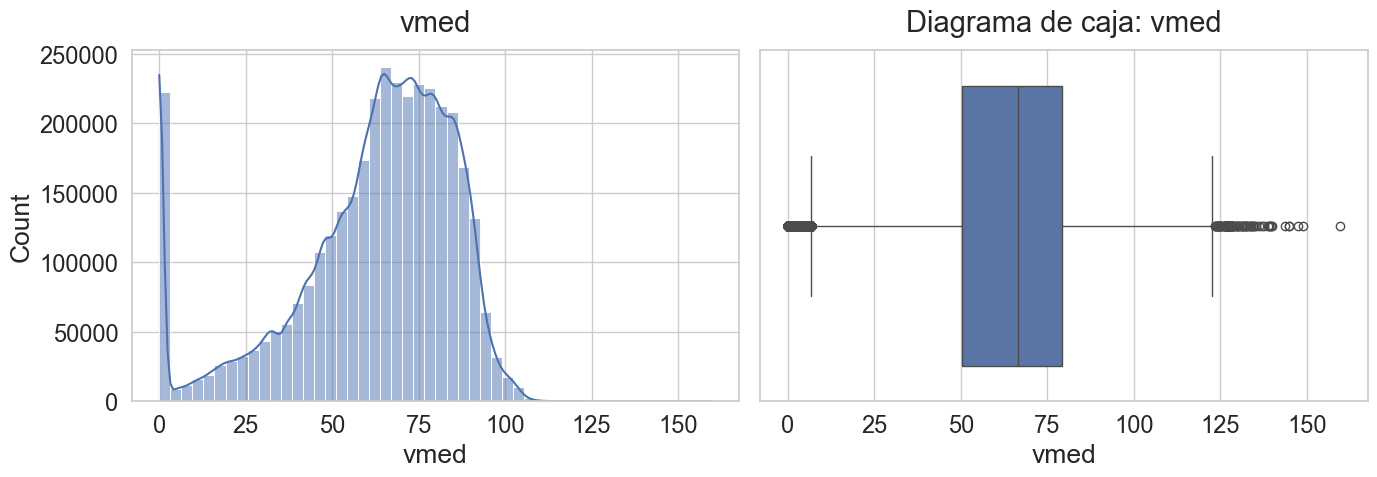

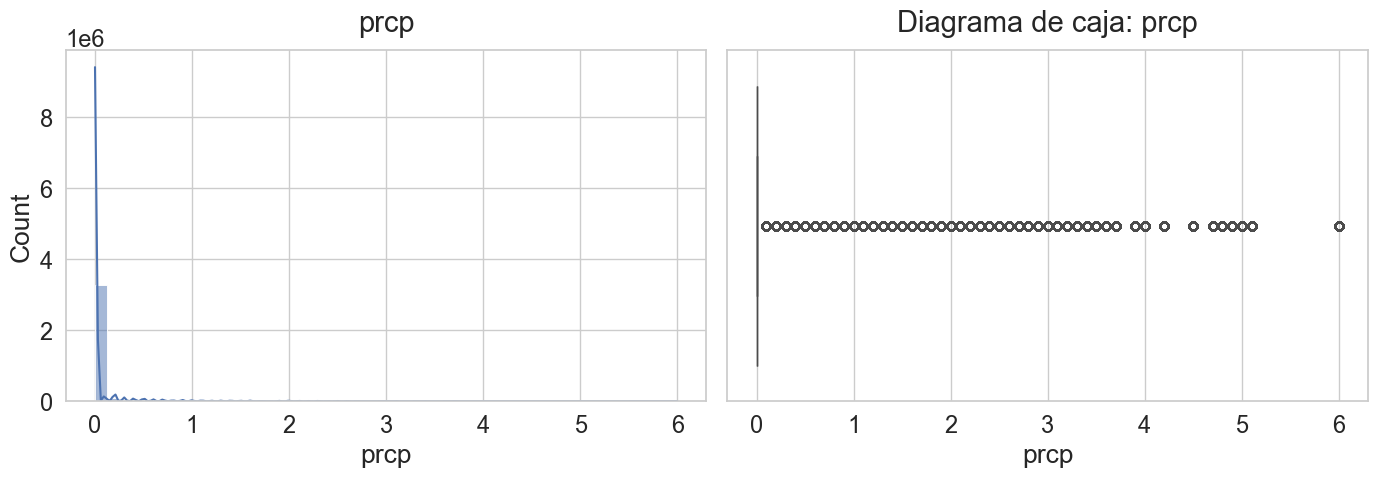

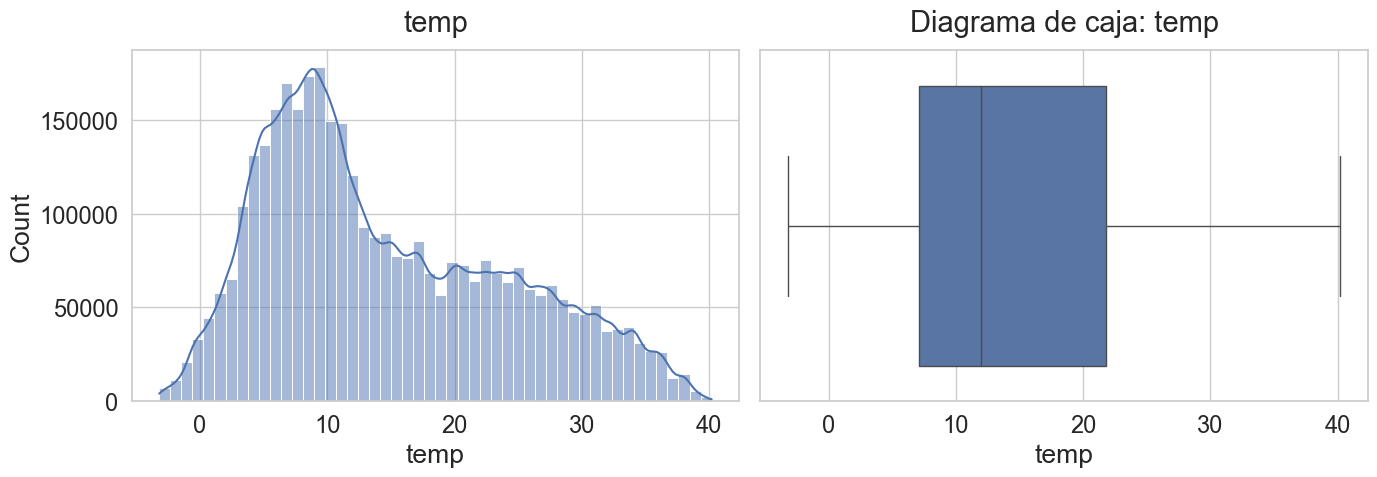

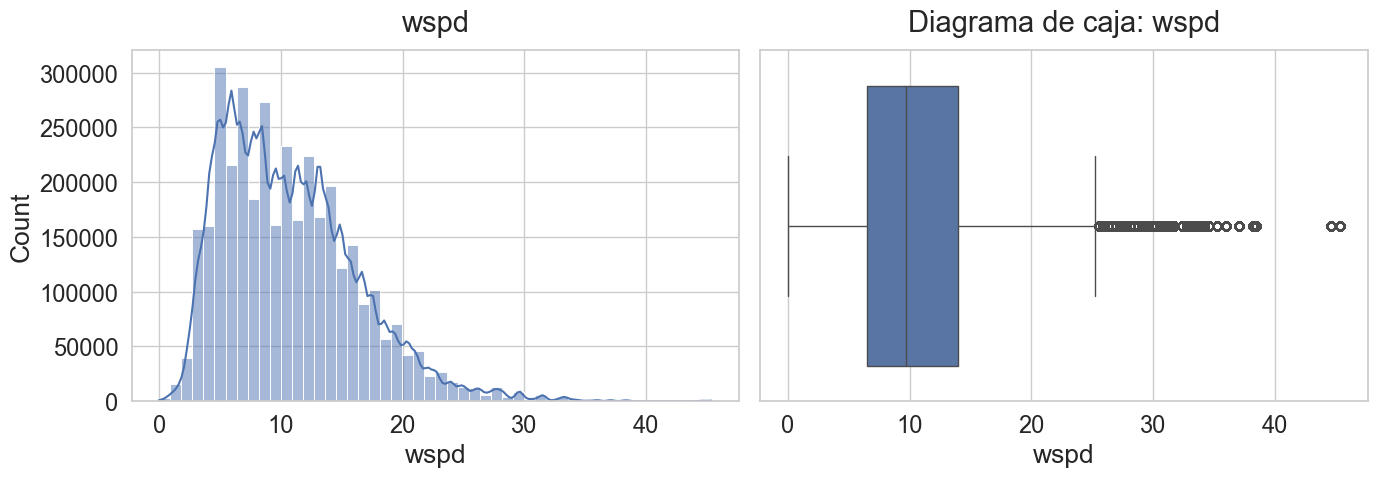

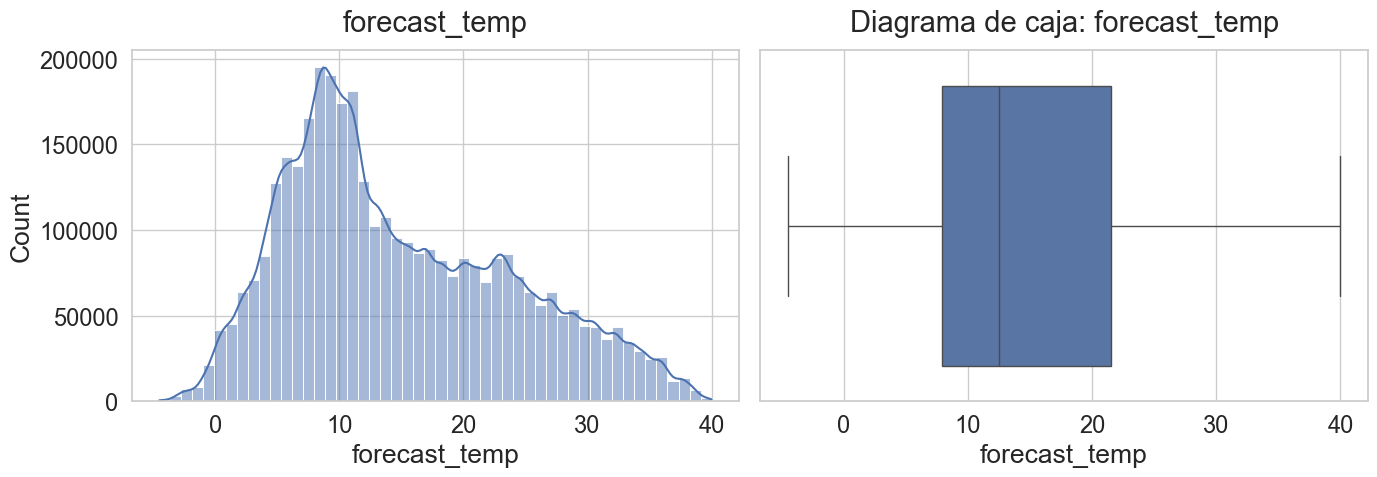

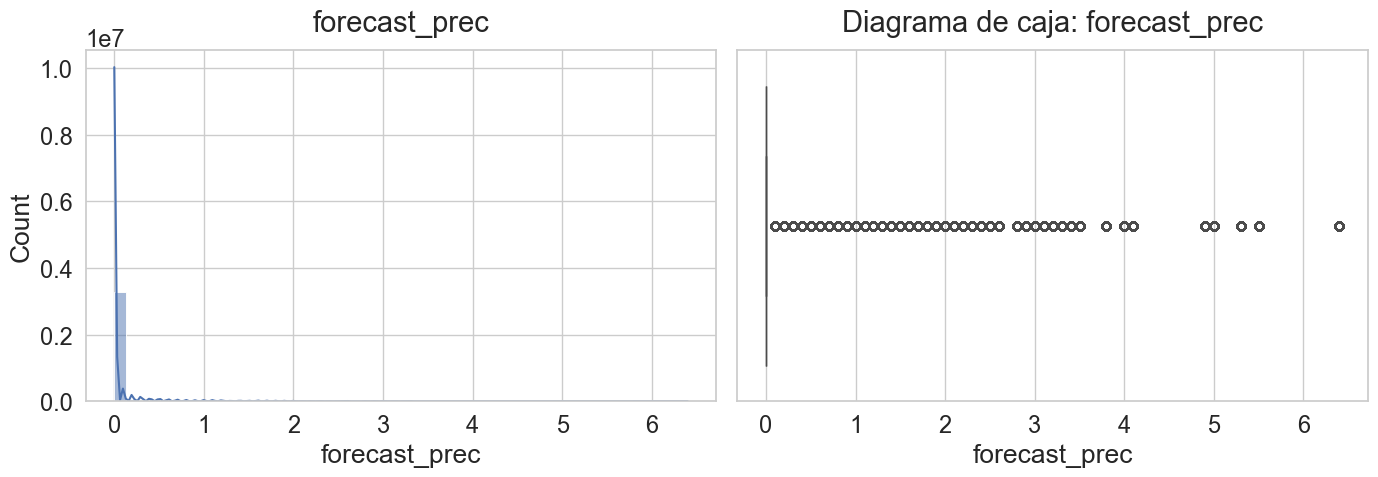

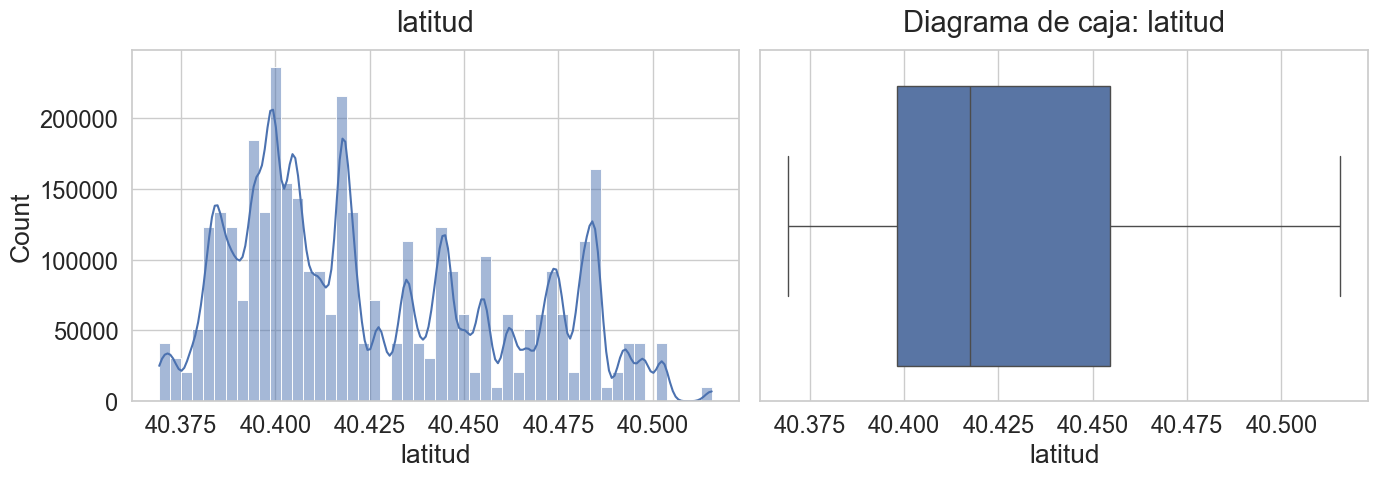

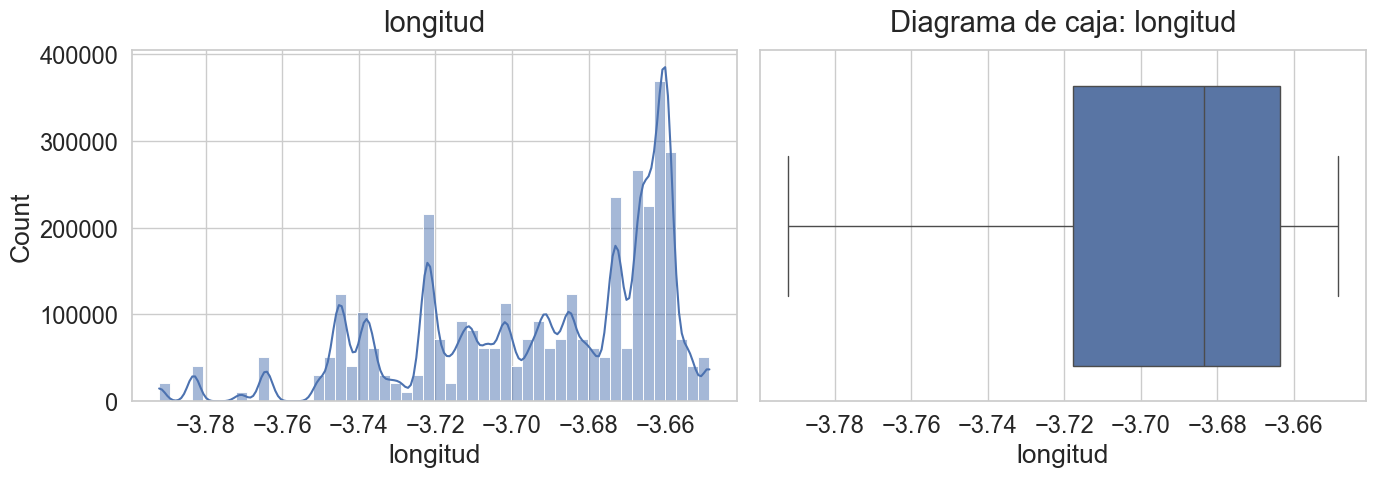

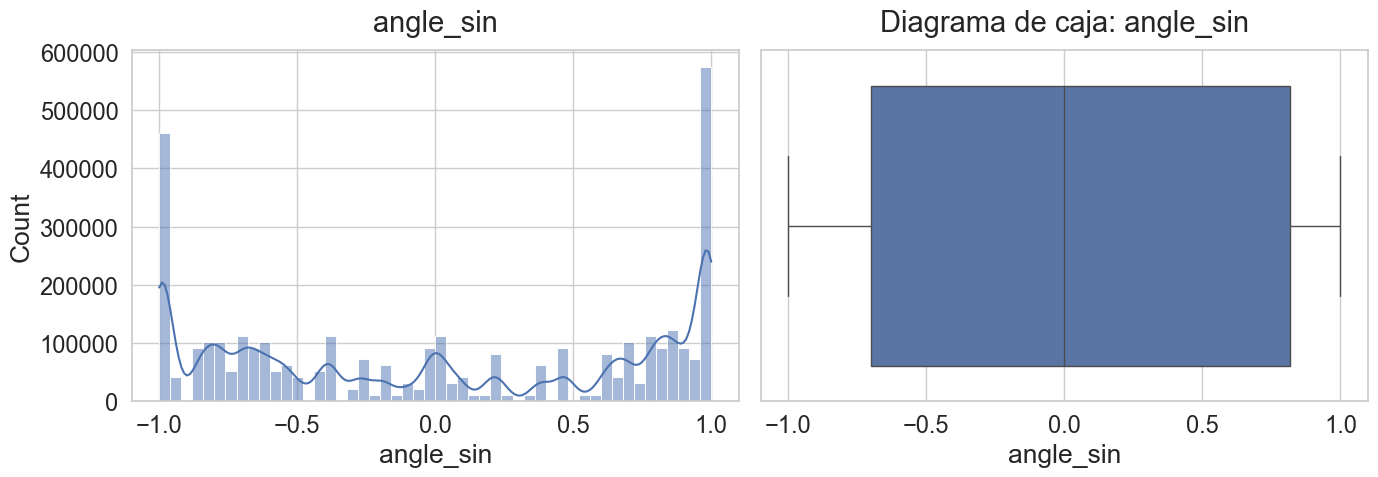

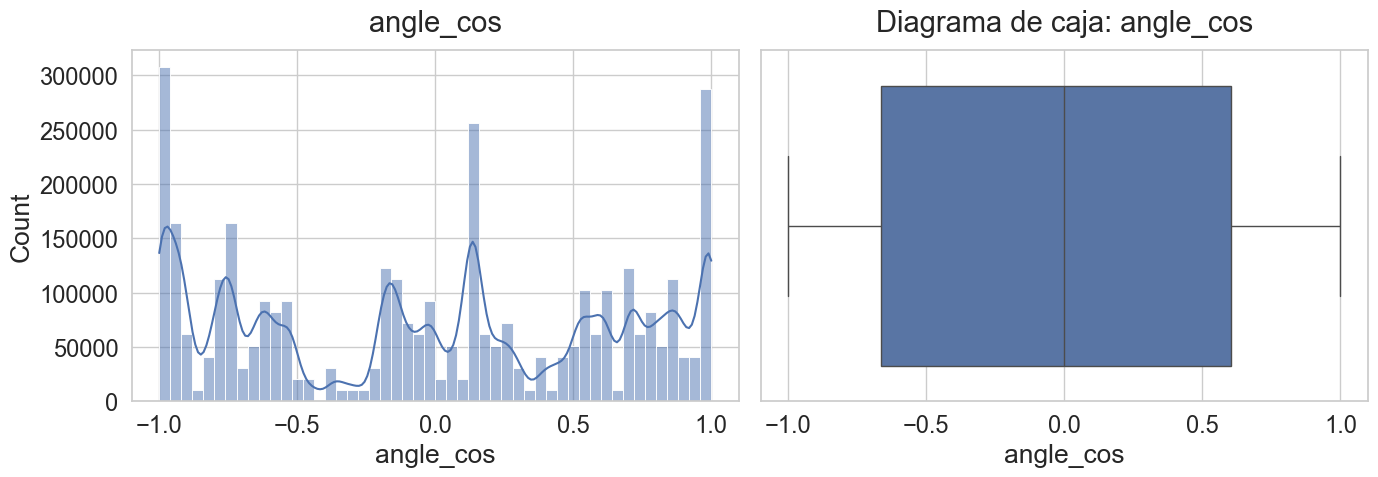

In [9]:
cont_no_target = [c for c in CONTINUOUS if c != 'intensidad']

for col in cont_no_target:
    with plt.rc_context(MULTI_RC):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.histplot(df[col], kde=True, bins=50, ax=axes[0])
        axes[0].set_title(col)
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f'Diagrama de caja: {col}')
        plt.tight_layout()
        plt.show()

## 5. Outlier detection (IQR method) — continuous variables

In [10]:
Q1 = df[CONTINUOUS].quantile(0.25)
Q3 = df[CONTINUOUS].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df[CONTINUOUS] < lower) | (df[CONTINUOUS] > upper)).sum()
outlier_pct = (outlier_counts / len(df) * 100).round(2)

pd.DataFrame({'outliers': outlier_counts, '% of total': outlier_pct})

,outliers,% of total
intensidad,142202,3.95
ocupacion,217677,6.05
vmed,231848,6.45
prcp,372762,10.36
temp,0,0.00
wspd,58617,1.63
forecast_temp,0,0.00
forecast_prec,454545,12.64
latitud,0,0.00
longitud,0,0.00


## 6. Correlation analysis

### 6.1 Pearson correlation — continuous variables

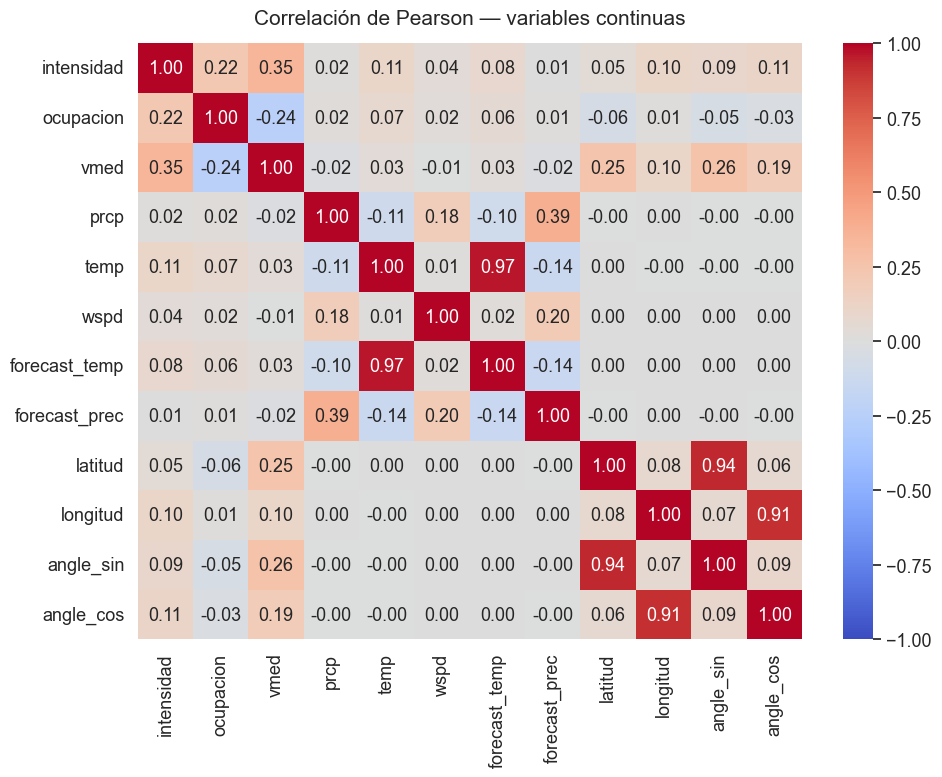

In [11]:
corr = df[CONTINUOUS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            annot_kws={'size': 13})
plt.title('Correlación de Pearson — variables continuas')
plt.tight_layout()
plt.show()

In [12]:
target_corr = corr['intensidad'].drop('intensidad').abs().sort_values(ascending=False)
print('Correlation with intensidad (abs):')
print(target_corr)

Correlation with intensidad (abs):
vmed             0.346246
ocupacion        0.220657
angle_cos        0.109848
temp             0.106686
longitud         0.102460
angle_sin        0.088129
forecast_temp    0.081671
latitud          0.046019
wspd             0.038121
prcp             0.015279
forecast_prec    0.005613
Name: intensidad, dtype: float64


### 6.1b Within-sensor correlation

The global Pearson correlation above mixes **between-sensor** and **within-sensor** variance. Since each sensor (`id`) has its own baseline traffic level, global correlations can be misleading (Simpson's paradox). To isolate the relationships the forecasting model will actually exploit, we:

1. **Demean by sensor** — subtract each sensor's mean, then correlate the residuals (removes between-sensor confound).
2. **Per-sensor correlation distribution** — compute the correlation with `intensidad` independently for each sensor and show the distribution.

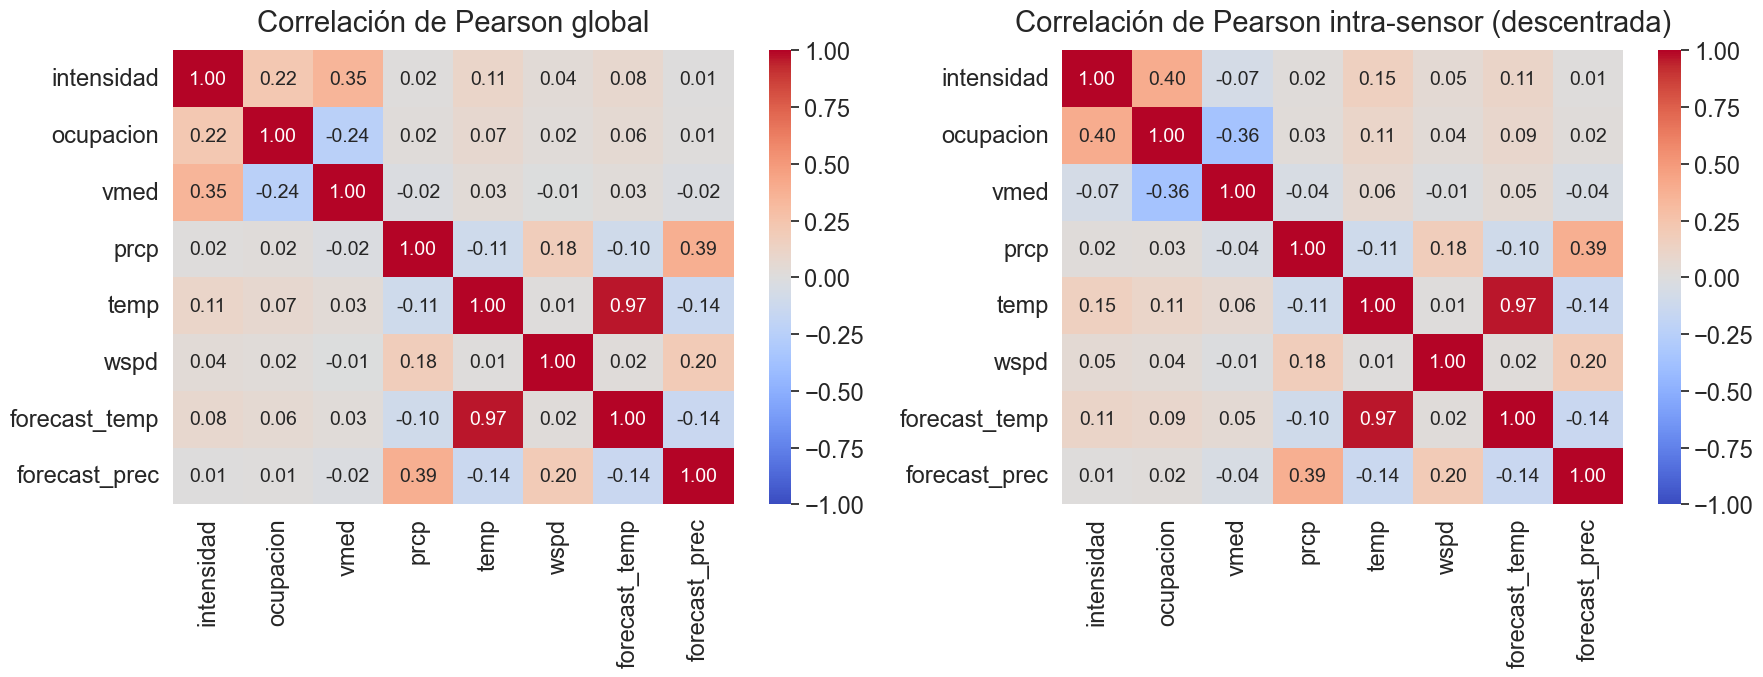

Correlación con intensidad — global vs intra-sensor:
               global  within-sensor  direction_change
ocupacion      0.2207         0.4005             False
vmed           0.3462        -0.0674              True
prcp           0.0153         0.0215             False
temp           0.1067         0.1500             False
wspd           0.0381         0.0536             False
forecast_temp  0.0817         0.1148             False
forecast_prec  0.0056         0.0079             False


In [13]:
# Demeaned (within-sensor) correlation
# Exclude latitud/longitud — constant per sensor, so demeaning yields zero variance
CONTINUOUS_TEMPORAL = [c for c in CONTINUOUS if c not in ('latitud', 'longitud', 'angle_sin', 'angle_cos')]

df_demeaned = df[CONTINUOUS_TEMPORAL].sub(df.groupby('id')[CONTINUOUS_TEMPORAL].transform('mean'))
corr_within = df_demeaned.corr()

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Global (original) — limited to time-varying continuous vars for comparability
    corr_temporal = df[CONTINUOUS_TEMPORAL].corr()
    sns.heatmap(corr_temporal, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
                ax=axes[0], annot_kws={'size': 14})
    axes[0].set_title('Correlación de Pearson global')

    # Within-sensor (demeaned)
    sns.heatmap(corr_within, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
                ax=axes[1], annot_kws={'size': 14})
    axes[1].set_title('Correlación de Pearson intra-sensor (descentrada)')

    plt.tight_layout()
    plt.show()

# Compare target correlations side by side
comparison = pd.DataFrame({
    'global': corr_temporal['intensidad'].drop('intensidad'),
    'within-sensor': corr_within['intensidad'].drop('intensidad'),
})
comparison['direction_change'] = (comparison['global'] * comparison['within-sensor']) < 0
print('Correlación con intensidad — global vs intra-sensor:')
print(comparison.round(4))

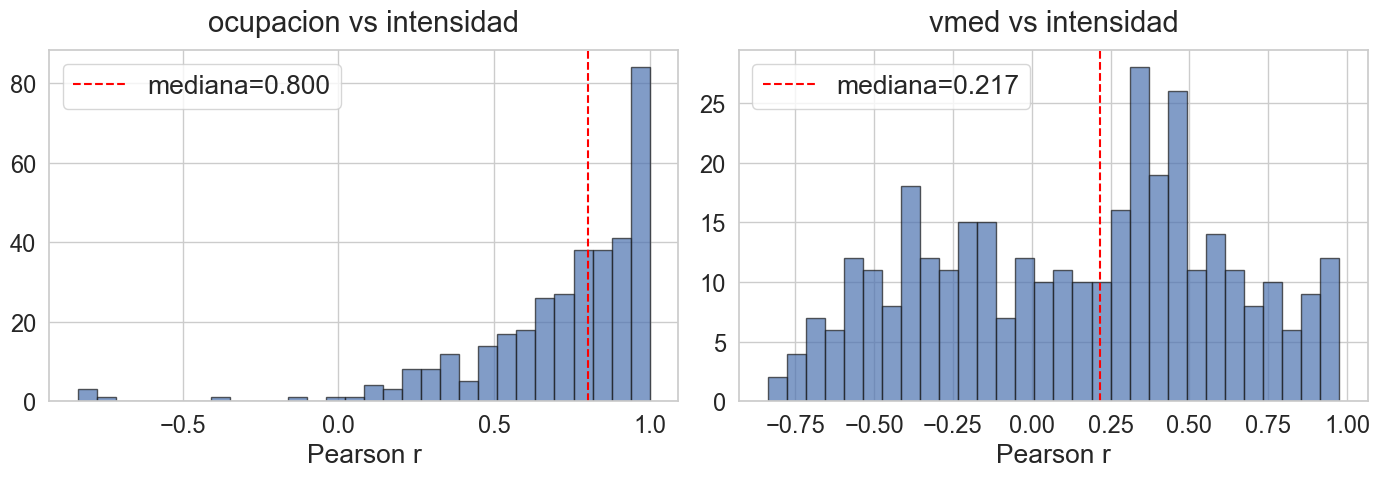

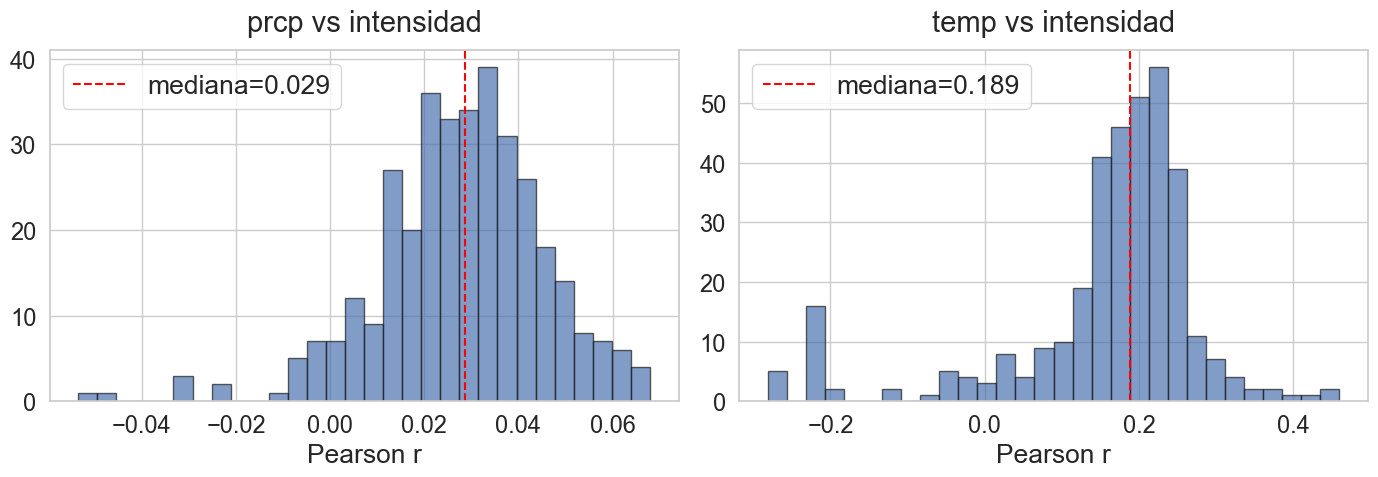

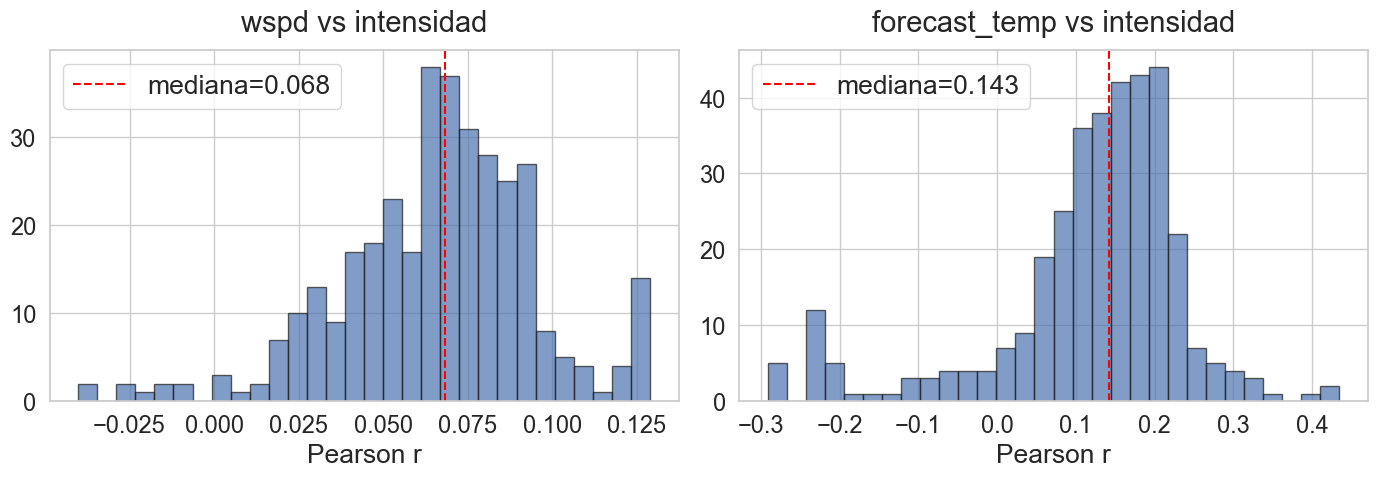

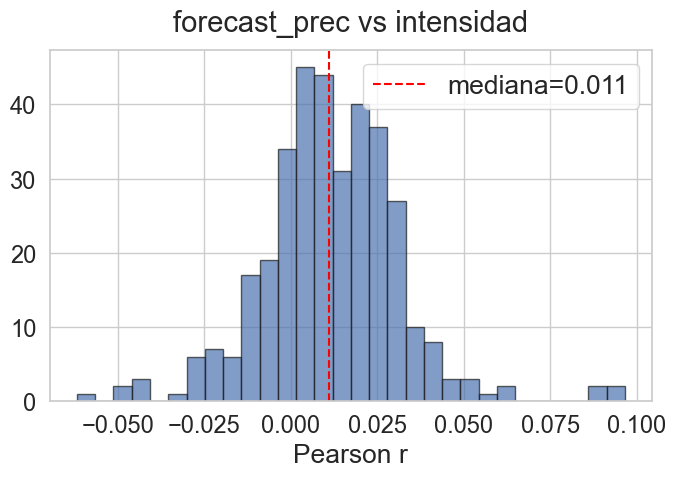

Distribución de correlaciones por sensor:
                mean    std    min    25%    50%    75%    max
variable                                                      
forecast_prec  0.012  0.020 -0.062  0.001  0.011  0.023  0.096
forecast_temp  0.119  0.126 -0.291  0.086  0.143  0.194  0.435
ocupacion      0.719  0.288 -0.836  0.605  0.800  0.933  0.999
prcp           0.028  0.018 -0.054  0.018  0.029  0.039  0.068
temp           0.157  0.130 -0.281  0.140  0.189  0.227  0.460
vmed           0.137  0.461 -0.838 -0.260  0.217  0.469  0.975
wspd           0.066  0.029 -0.040  0.050  0.068  0.084  0.129


In [14]:
# Per-sensor correlation distribution with intensidad
# Exclude latitud/longitud — constant per sensor, correlation is undefined
per_sensor_corr = (
    df.groupby('id')[CONTINUOUS_TEMPORAL]
    .corr()
    .loc[:, 'intensidad']
    .reset_index()
    .rename(columns={'level_1': 'variable', 'intensidad': 'correlation'})
    .query("variable != 'intensidad'")
)

plot_vars = [c for c in CONTINUOUS_TEMPORAL if c != 'intensidad']

def plot_corr_row(vars_pair):
    with plt.rc_context(MULTI_RC):
        n = len(vars_pair)
        fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
        if n == 1:
            axes = [axes]
        for ax, var in zip(axes, vars_pair):
            data = per_sensor_corr[per_sensor_corr['variable'] == var]['correlation']
            ax.hist(data, bins=30, edgecolor='k', alpha=0.7)
            ax.axvline(data.median(), color='red', linestyle='--',
                       label=f'mediana={data.median():.3f}')
            ax.set_title(f'{var} vs intensidad')
            ax.set_xlabel('Pearson r')
            ax.legend()
        plt.tight_layout()
        plt.show()

for i in range(0, len(plot_vars), 2):
    plot_corr_row(plot_vars[i:i + 2])

# Summary statistics
summary = per_sensor_corr.groupby('variable')['correlation'].describe().round(3)
print('Distribución de correlaciones por sensor:')
print(summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

### 6.2 Categorical variables vs `intensidad`

For categorical features, Pearson correlation is not appropriate. Instead we use:
- **Boxplots / violin plots** to visualise how the target distribution shifts across categories.
- **Eta-squared (η²)** — the ratio of between-group variance to total variance (analogous to R² from a one-way ANOVA). Values close to 0 indicate no relationship; values close to 1 indicate that category membership explains most of the variance in `intensidad`.

In [15]:
def eta_squared(df, categorical_col, continuous_col):
    """Compute eta-squared (ANOVA effect size) between a categorical and continuous variable."""
    groups = df.groupby(categorical_col)[continuous_col]
    grand_mean = df[continuous_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for _, g in groups)
    ss_total = ((df[continuous_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total != 0 else 0.0

eta2_results = {col: eta_squared(df, col, 'intensidad') for col in CATEGORICAL}
eta2_series = pd.Series(eta2_results).sort_values(ascending=False)

print('Eta-squared (η²) — effect size of each categorical variable on intensidad:')
print(eta2_series.round(4))

Eta-squared (η²) — effect size of each categorical variable on intensidad:
hora_dia           0.2249
distrito           0.0557
dia_semana         0.0088
mes                0.0050
coco               0.0050
cldc               0.0036
festivo            0.0021
vispera_festivo    0.0002
dtype: float64


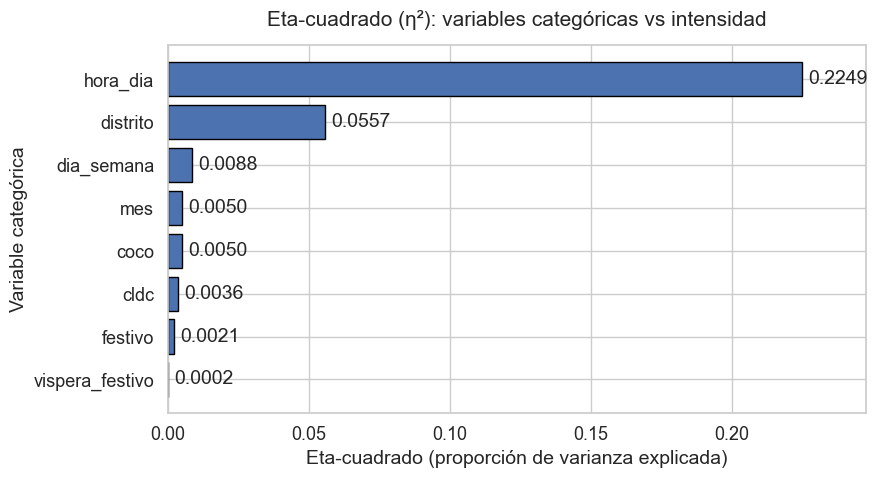

In [16]:
eta2_plot = eta2_series.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    eta2_plot.index,
    eta2_plot.values,
    edgecolor='black'
)

ax.set_title('Eta-cuadrado (η²): variables categóricas vs intensidad')
ax.set_xlabel('Eta-cuadrado (proporción de varianza explicada)')
ax.set_ylabel('Variable categórica')
ax.set_xlim(0, max(eta2_plot.max() * 1.1, 0.01))

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + eta2_plot.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [17]:
# Eta-squared global vs within-sensor for categorical variables

def eta_squared_from_series(cat, y):
    """Compute eta-squared between a categorical variable and a continuous Series."""
    valid = cat.notna() & y.notna()
    cat_valid = cat[valid]
    y_valid = y[valid]

    grand_mean = y_valid.mean()
    ss_total = ((y_valid - grand_mean) ** 2).sum()

    if ss_total == 0:
        return 0.0

    ss_between = 0.0
    for _, group_idx in cat_valid.groupby(cat_valid).groups.items():
        group_y = y_valid.loc[group_idx]
        ss_between += len(group_y) * (group_y.mean() - grand_mean) ** 2

    return ss_between / ss_total


# Demean target by sensor
df['intensidad_within_sensor'] = (
        df['intensidad'] - df.groupby('id')['intensidad'].transform('mean')
)

eta2_global = {
    col: eta_squared_from_series(df[col], df['intensidad'])
    for col in CATEGORICAL
}

eta2_within = {
    col: eta_squared_from_series(df[col], df['intensidad_within_sensor'])
    for col in CATEGORICAL
}

eta2_comparison = pd.DataFrame({
    'eta2_global': eta2_global,
    'eta2_within_sensor': eta2_within
})

eta2_comparison['difference'] = (
        eta2_comparison['eta2_within_sensor'] - eta2_comparison['eta2_global']
)

eta2_comparison = eta2_comparison.sort_values(
    'eta2_within_sensor',
    ascending=False
)

display(eta2_comparison.round(4))

,eta2_global,eta2_within_sensor,difference
hora_dia,0.2249,0.4446,0.2196
dia_semana,0.0088,0.0174,0.0086
mes,0.0050,0.0099,0.0049
coco,0.0050,0.0099,0.0049
cldc,0.0036,0.0072,0.0036
festivo,0.0021,0.0042,0.0021
vispera_festivo,0.0002,0.0003,0.0002
distrito,0.0557,0.0000,-0.0557


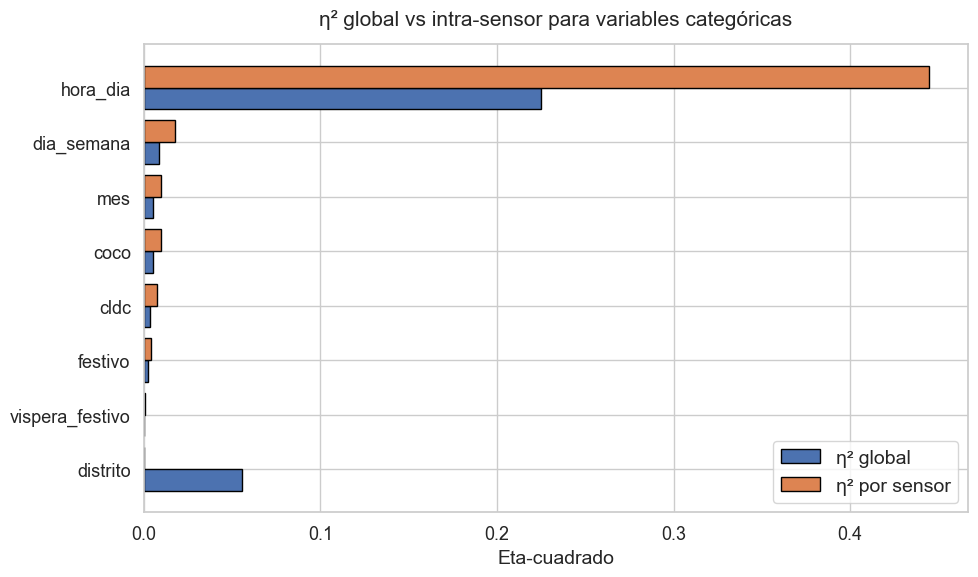

In [18]:
eta2_plot = eta2_comparison.sort_values('eta2_within_sensor', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(eta2_plot))

ax.barh(
    [y - 0.2 for y in y_pos],
    eta2_plot['eta2_global'],
    height=0.4,
    label='η² global',
    edgecolor='black'
)

ax.barh(
    [y + 0.2 for y in y_pos],
    eta2_plot['eta2_within_sensor'],
    height=0.4,
    label='η² por sensor',
    edgecolor='black'
)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(eta2_plot.index)

ax.set_xlabel('Eta-cuadrado')
ax.set_title('η² global vs intra-sensor para variables categóricas')
ax.legend()

plt.tight_layout()
plt.show()

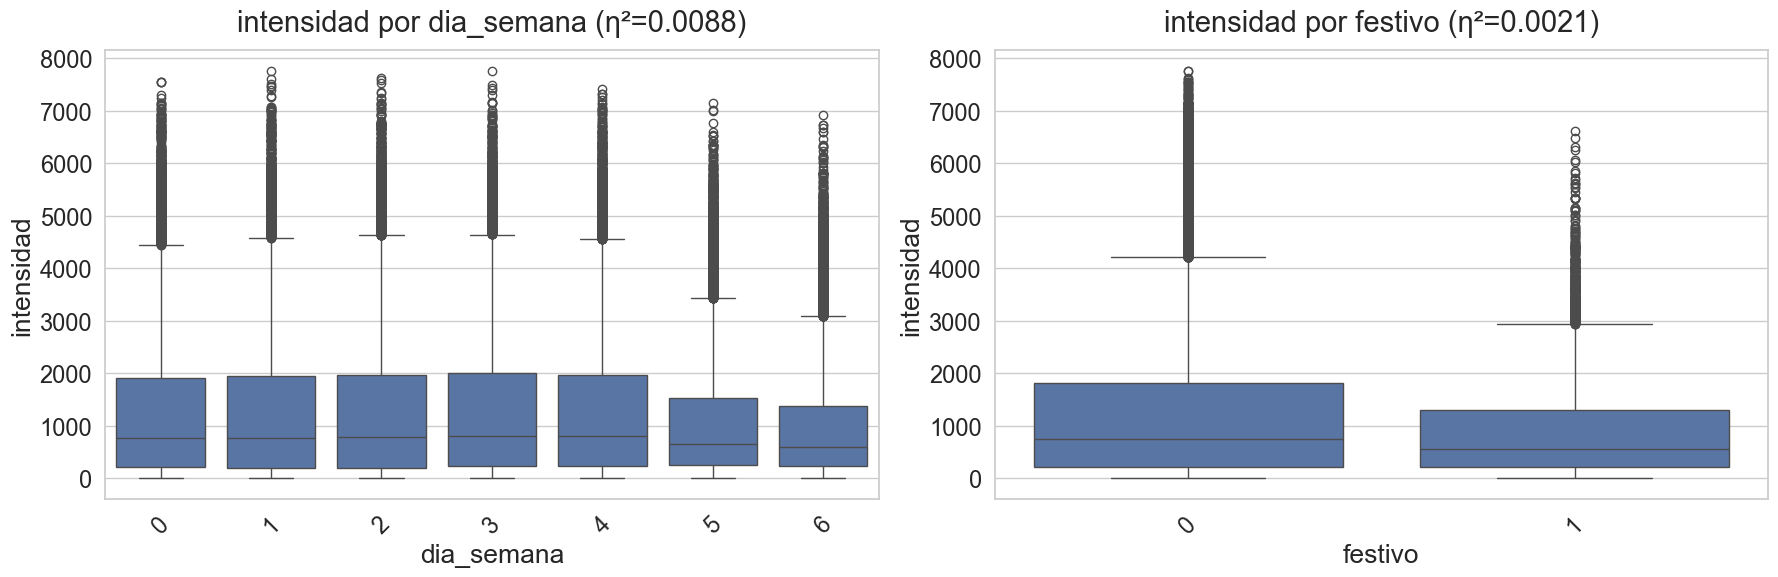

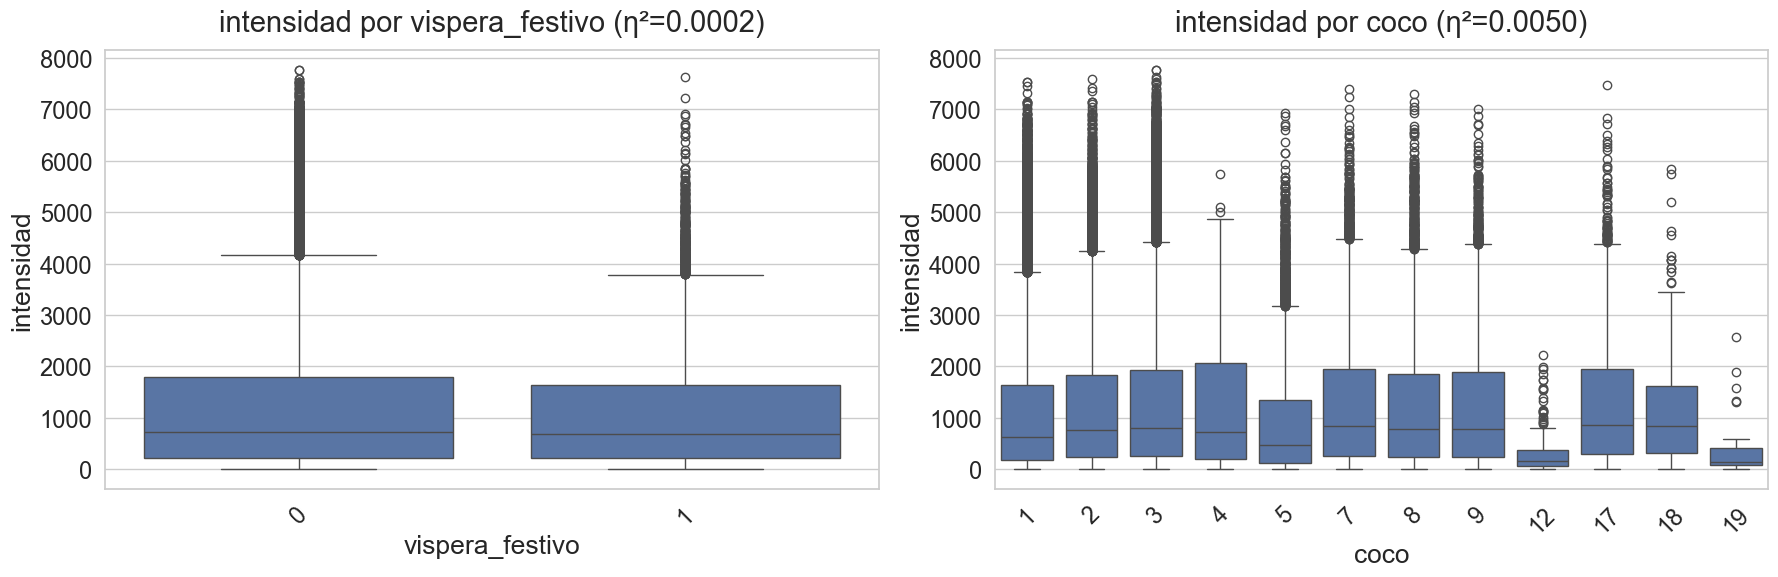

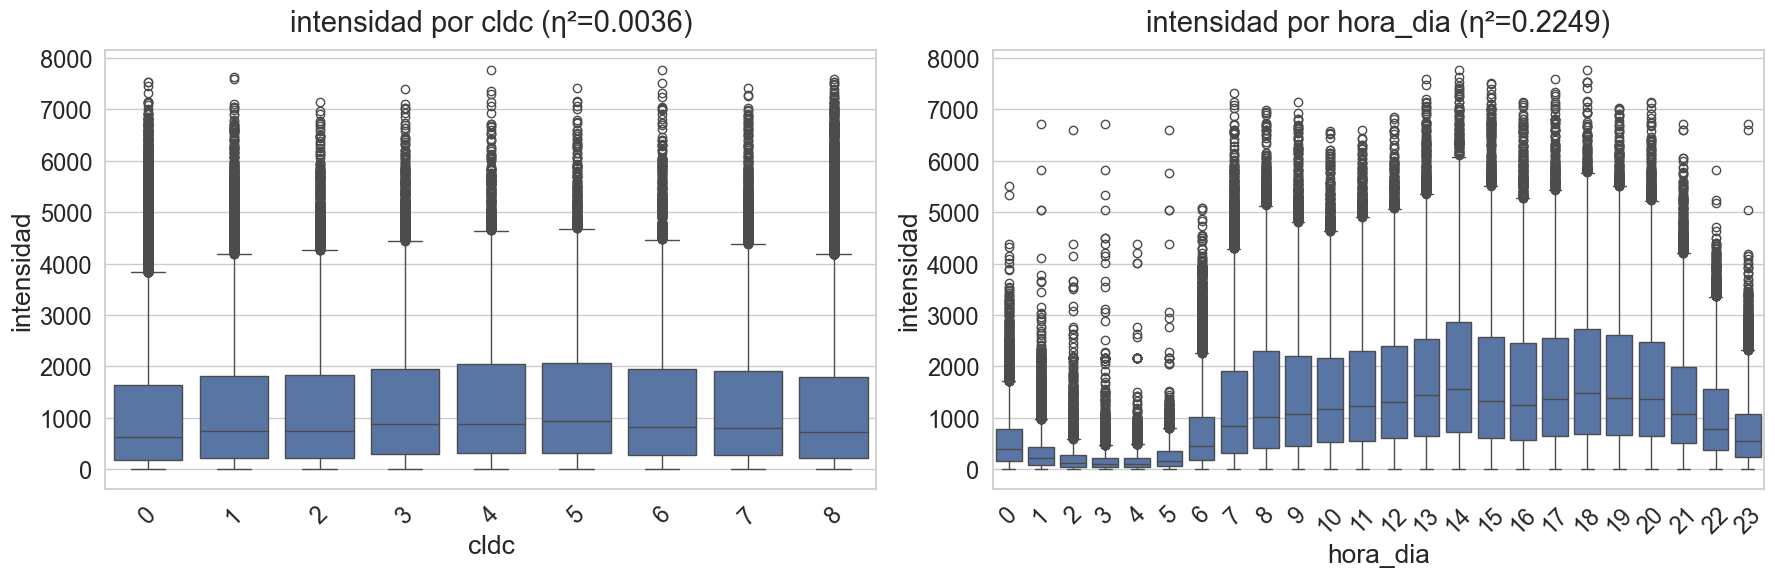

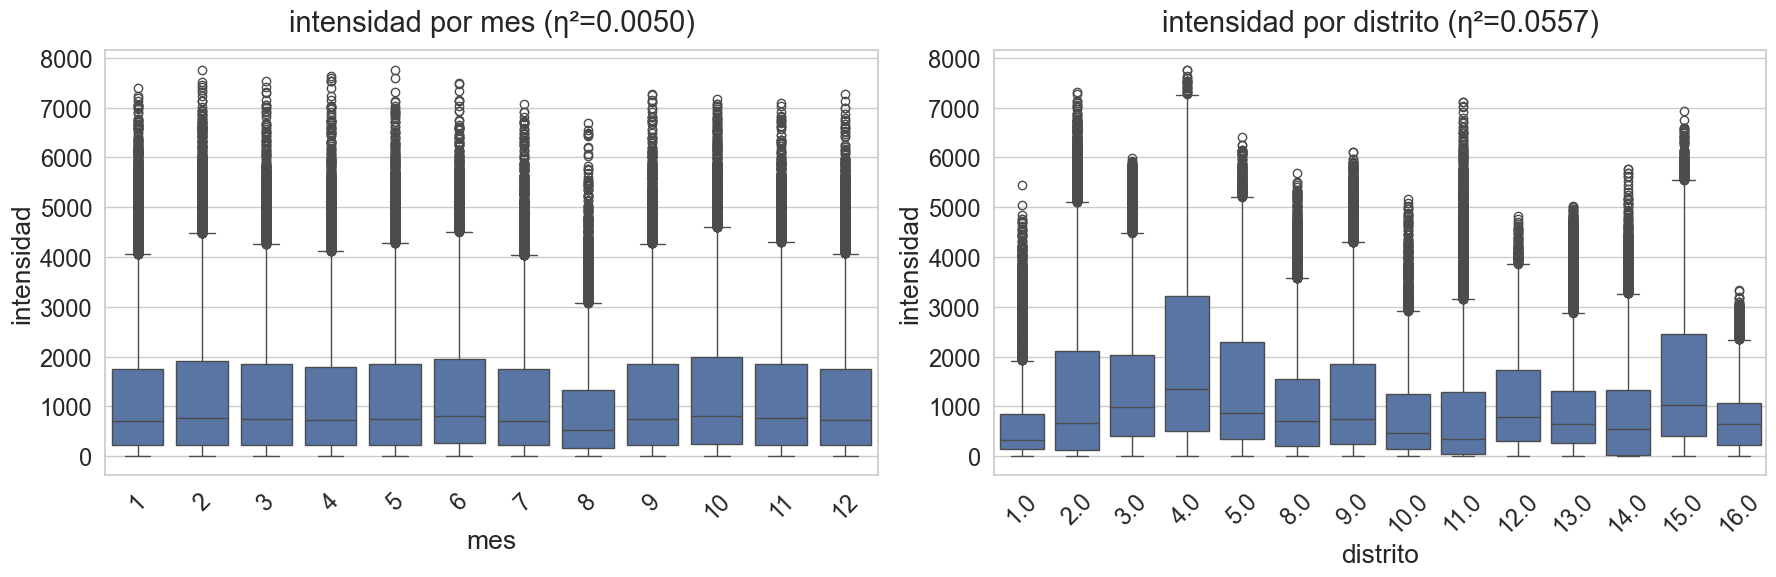

In [19]:
df_sample = df.sample(n=200_000, random_state=42)

def plot_boxrow_traffic(cols):
    with plt.rc_context(MULTI_RC):
        n = len(cols)
        fig, axes = plt.subplots(1, n, figsize=(9 * n, 6))
        if n == 1:
            axes = [axes]
        for ax, col in zip(axes, cols):
            sns.boxplot(data=df_sample, x=col, y='intensidad', ax=ax)
            ax.set_title(f'intensidad por {col} (η²={eta2_results[col]:.4f})')
            ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

for i in range(0, len(CATEGORICAL), 2):
    plot_boxrow_traffic(CATEGORICAL[i:i + 2])

## 7. Temporal patterns

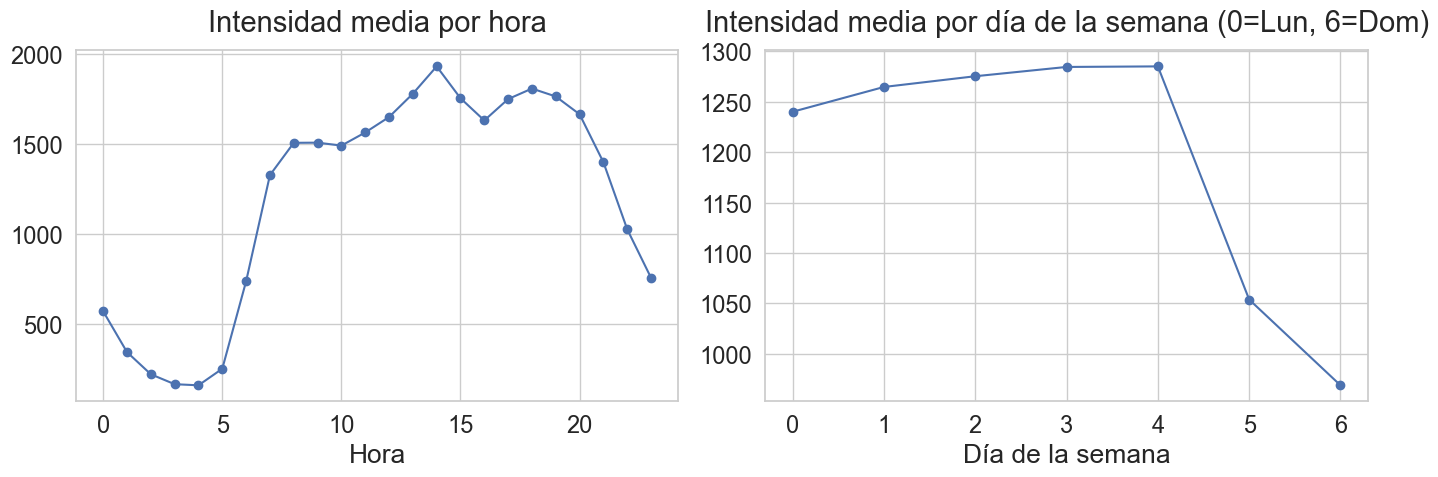

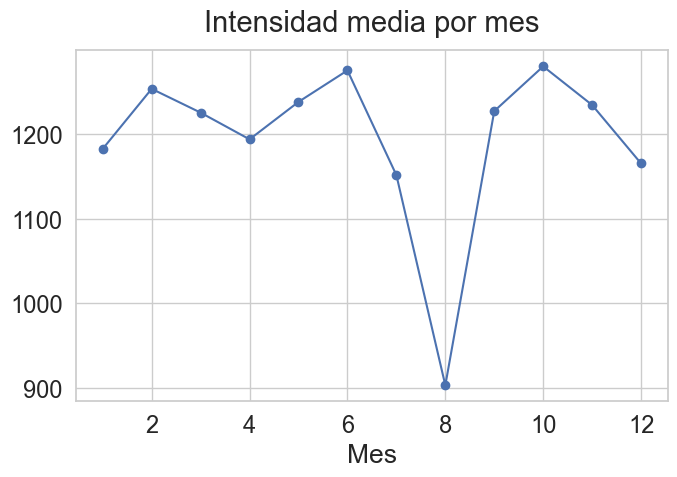

In [20]:
with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df.groupby('hora_dia')['intensidad'].mean().plot(ax=axes[0], marker='o')
    axes[0].set_title('Intensidad media por hora')
    axes[0].set_xlabel('Hora')
    df.groupby('dia_semana')['intensidad'].mean().plot(ax=axes[1], marker='o')
    axes[1].set_title('Intensidad media por día de la semana (0=Lun, 6=Dom)')
    axes[1].set_xlabel('Día de la semana')
    plt.tight_layout(); plt.show()

with plt.rc_context(MULTI_RC):
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    df.groupby('mes')['intensidad'].mean().plot(ax=ax, marker='o')
    ax.set_title('Intensidad media por mes')
    ax.set_xlabel('Mes')
    plt.tight_layout(); plt.show()

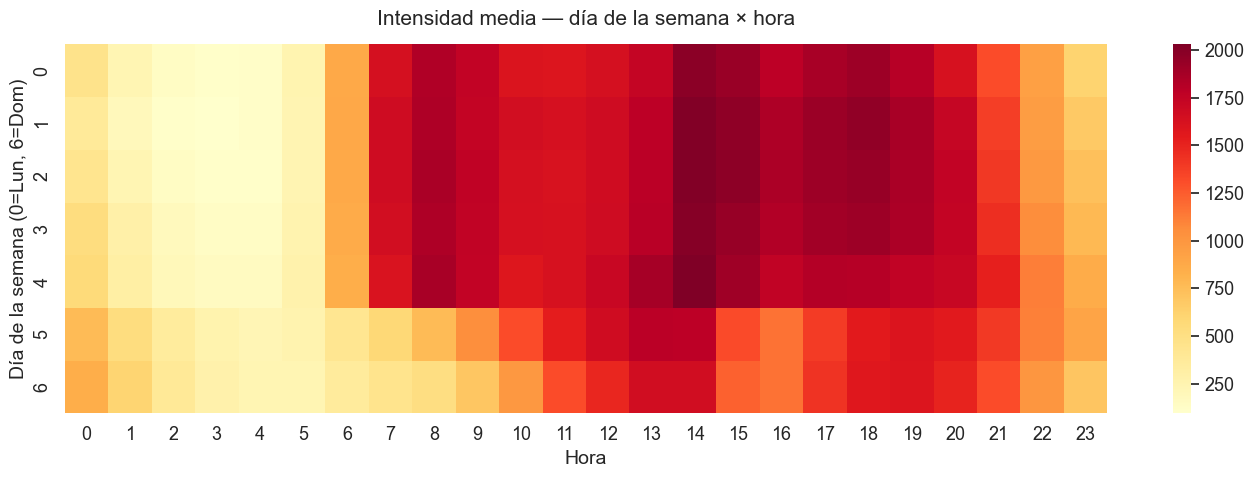

In [21]:
pivot = df.groupby(['dia_semana', 'hora_dia'])['intensidad'].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False)
plt.title('Intensidad media — día de la semana × hora')
plt.ylabel('Día de la semana (0=Lun, 6=Dom)')
plt.xlabel('Hora')
plt.tight_layout()
plt.show()

## 8. Spatial variables: `latitud`, `longitud`, `distrito`

The dataset includes the geographic coordinates (`latitud`, `longitud`) and administrative district (`distrito`) for each sensor. These variables capture the spatial dimension of traffic patterns — sensors in different locations and districts may exhibit structurally different traffic intensities due to road type, proximity to commercial/residential areas, and urban topology.

### 8.1 Descriptive statistics and sensor distribution by district

--- latitud ---
count    3.597048e+06
mean     4.042643e+01
std      3.538343e-02
min      4.036920e+01
25%      4.039802e+01
50%      4.041747e+01
75%      4.045447e+01
max      4.051561e+01
Name: latitud, dtype: float64

--- longitud ---
count    3.597048e+06
mean    -3.692024e+00
std      3.271527e-02
min     -3.792246e+00
25%     -3.717736e+00
50%     -3.683397e+00
75%     -3.663496e+00
max     -3.648389e+00
Name: longitud, dtype: float64

--- distrito ---
Unique districts: 14
Districts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]

Sensors per distrito:
distrito
1      7
2     42
3     25
4     19
5     25
8     40
9     38
10    18
11    22
12    16
13    26
14    26
15    39
16     8
Name: id, dtype: int64


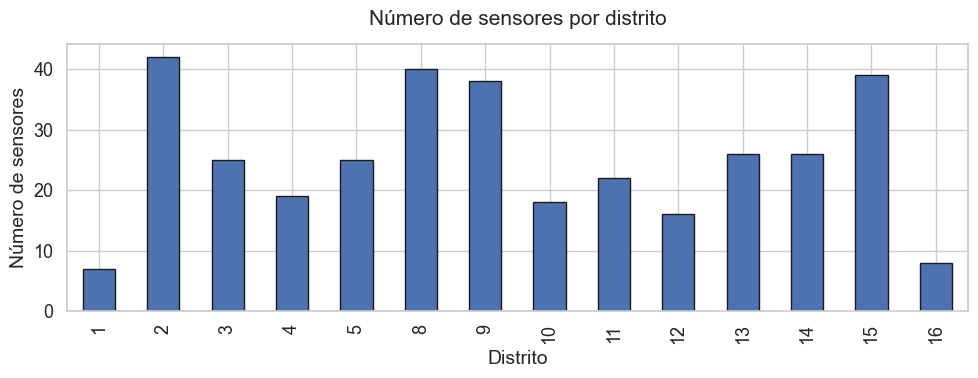

In [22]:
# Descriptive stats for spatial variables
print('--- latitud ---')
print(df['latitud'].describe())
print(f'\n--- longitud ---')
print(df['longitud'].describe())

# distrito: treat as categorical (integer district codes)
distrito_int = df['distrito'].astype(int)
print(f'\n--- distrito ---')
print(f'Unique districts: {distrito_int.nunique()}')
print(f'Districts: {sorted(distrito_int.unique())}')

# Number of sensors per district
sensors_per_distrito = df.groupby(distrito_int)['id'].nunique().sort_index()
print(f'\nSensors per distrito:')
print(sensors_per_distrito)

fig, ax = plt.subplots(figsize=(10, 4))
sensors_per_distrito.plot(kind='bar', ax=ax, edgecolor='k')
ax.set_title('Número de sensores por distrito')
ax.set_xlabel('Distrito')
ax.set_ylabel('Número de sensores')
plt.tight_layout()
plt.show()

### 8.2 Spatial distribution of sensors (scatter map)

/var/folders/jp/g9h79w4s2kvbjnyv8klyykqw0000gn/T/ipykernel_41263/3345808218.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_d = plt.cm.get_cmap('tab20', len(distritos_sorted))


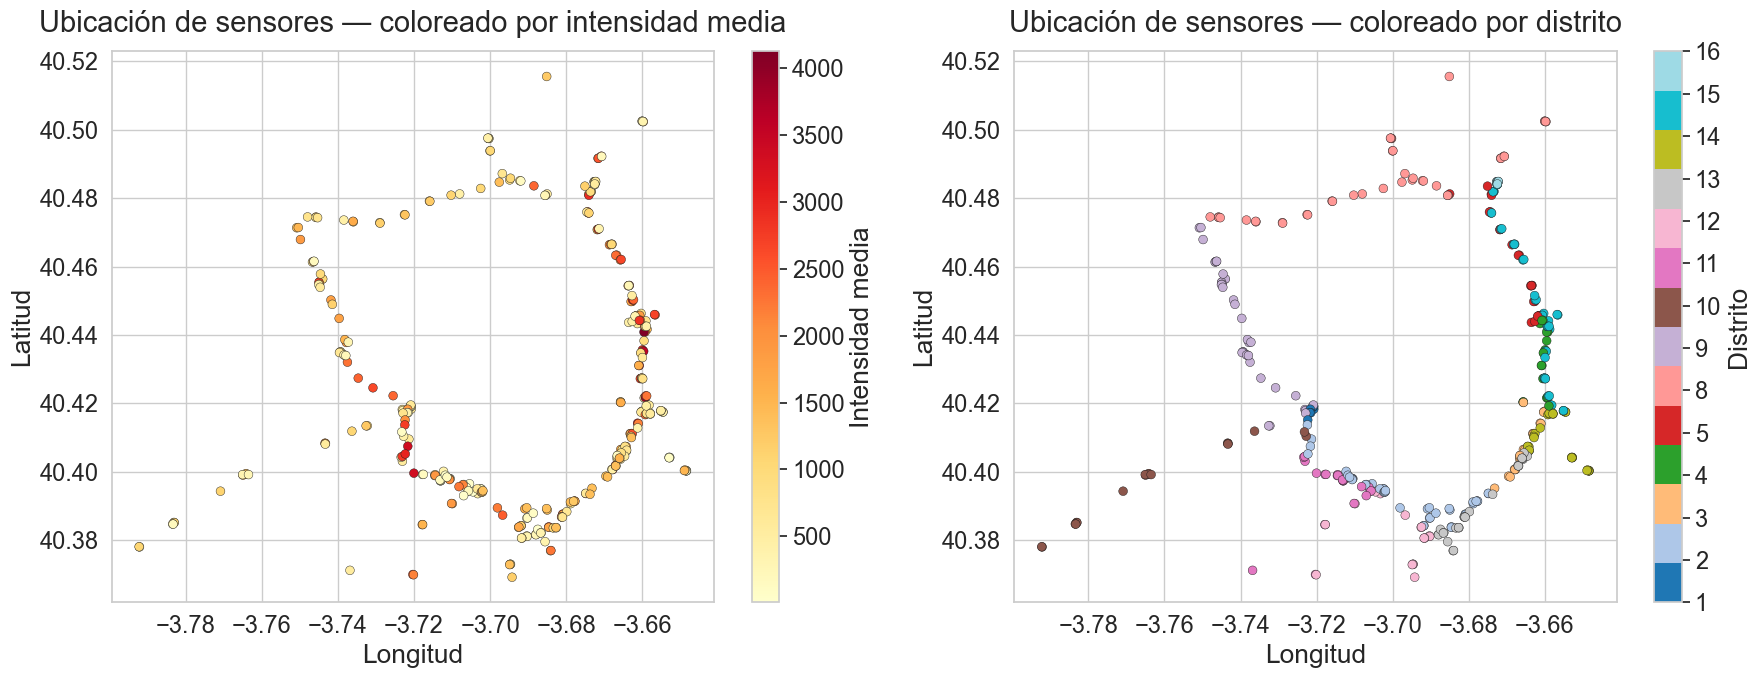

In [23]:
sensor_stats = (
    df.groupby('id')
    .agg(latitud=('latitud', 'first'),
         longitud=('longitud', 'first'),
         distrito=('distrito', 'first'),
         mean_intensidad=('intensidad', 'mean'))
    .reset_index()
)
sensor_stats['distrito'] = sensor_stats['distrito'].astype(int)

distritos_sorted = sorted(sensor_stats['distrito'].unique())

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Coloured by mean intensidad
    sc = axes[0].scatter(sensor_stats['longitud'], sensor_stats['latitud'],
                         c=sensor_stats['mean_intensidad'], cmap='YlOrRd', s=40, edgecolors='k', linewidth=0.3)
    plt.colorbar(sc, ax=axes[0], label='Intensidad media')
    axes[0].set_title('Ubicación de sensores — coloreado por intensidad media')
    axes[0].set_xlabel('Longitud')
    axes[0].set_ylabel('Latitud')

    # Coloured by distrito
    cmap_d = plt.cm.get_cmap('tab20', len(distritos_sorted))
    distrito_map = {d: i for i, d in enumerate(distritos_sorted)}
    colors = [distrito_map[d] for d in sensor_stats['distrito']]
    sc2 = axes[1].scatter(sensor_stats['longitud'], sensor_stats['latitud'],
                          c=colors, cmap=cmap_d, s=40, edgecolors='k', linewidth=0.3)
    cbar = plt.colorbar(sc2, ax=axes[1], ticks=range(len(distritos_sorted)))
    cbar.ax.set_yticklabels(distritos_sorted)
    cbar.set_label('Distrito')
    axes[1].set_title('Ubicación de sensores — coloreado por distrito')
    axes[1].set_xlabel('Longitud')
    axes[1].set_ylabel('Latitud')

    plt.tight_layout()
    plt.show()

### 8.3 Intensidad by distrito

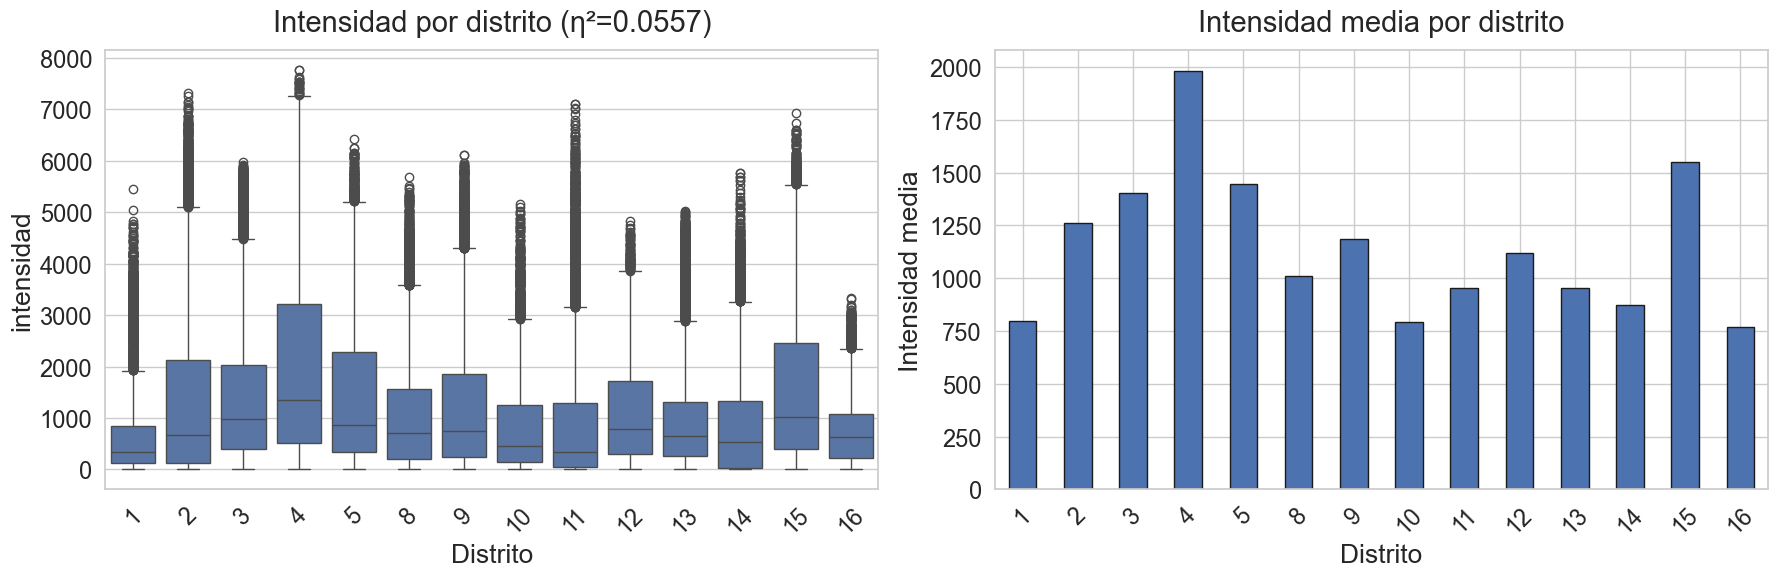

Eta-cuadrado (distrito → intensidad): 0.0557

Intensidad media por distrito:
distrito_int
1      796.0
2     1261.2
3     1401.0
4     1979.0
5     1447.8
8     1008.8
9     1183.6
10     792.0
11     951.0
12    1119.9
13     953.6
14     872.1
15    1548.3
16     770.4
Name: intensidad, dtype: float64


In [24]:
df['distrito_int'] = df['distrito'].astype(int)

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Boxplot
    sns.boxplot(data=df_sample.assign(distrito_int=df_sample['distrito'].astype(int)),
                x='distrito_int', y='intensidad', ax=axes[0], order=distritos_sorted)
    eta2_distrito = eta_squared(df, 'distrito_int', 'intensidad')
    axes[0].set_title(f'Intensidad por distrito (η²={eta2_distrito:.4f})')
    axes[0].set_xlabel('Distrito')
    axes[0].tick_params(axis='x', rotation=45)

    # Mean intensidad per distrito (bar chart)
    mean_by_distrito = df.groupby('distrito_int')['intensidad'].mean().sort_index()
    mean_by_distrito.plot(kind='bar', ax=axes[1], edgecolor='k')
    axes[1].set_title('Intensidad media por distrito')
    axes[1].set_xlabel('Distrito')
    axes[1].set_ylabel('Intensidad media')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

print(f'Eta-cuadrado (distrito → intensidad): {eta2_distrito:.4f}')
print(f'\nIntensidad media por distrito:')
print(mean_by_distrito.round(1))

### 8.4 Temporal patterns by distrito

How the hourly traffic profile varies across districts — reveals whether all districts follow the same daily curve or if some have structurally different patterns.

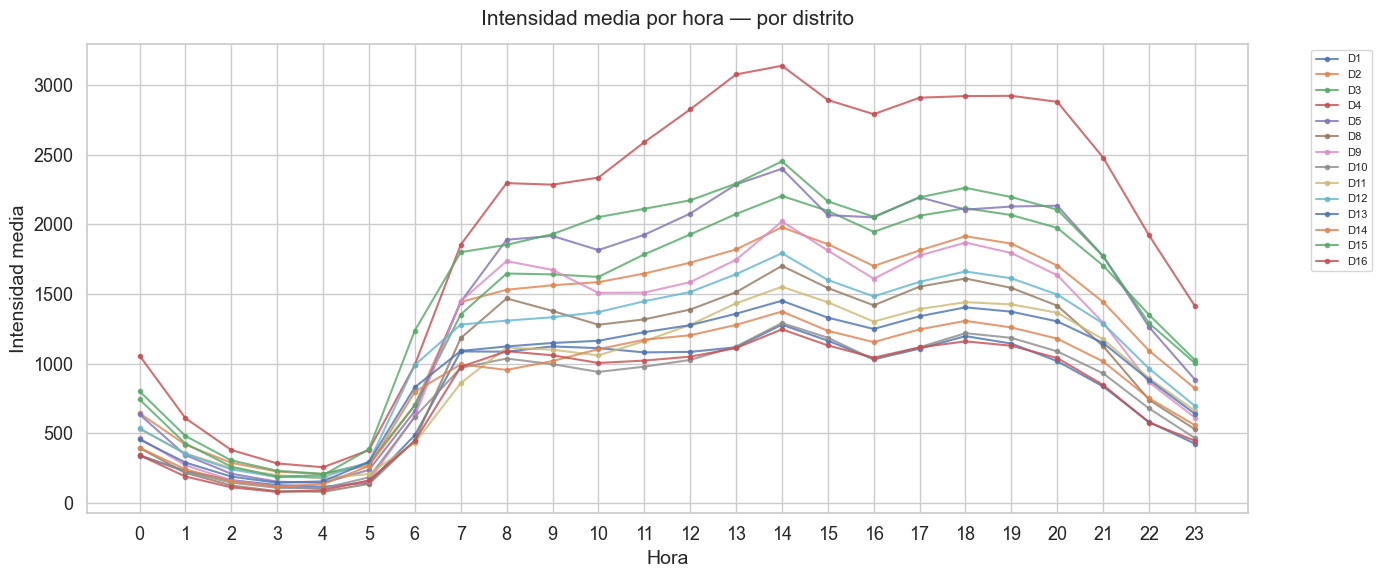

In [25]:
hourly_by_distrito = df.groupby(['distrito_int', 'hora_dia'])['intensidad'].mean().unstack(level=0)

fig, ax = plt.subplots(figsize=(14, 6))
for distrito in distritos_sorted:
    ax.plot(hourly_by_distrito.index, hourly_by_distrito[distrito], marker='.', label=f'D{distrito}', alpha=0.8)
ax.set_title('Intensidad media por hora — por distrito')
ax.set_xlabel('Hora')
ax.set_ylabel('Intensidad media')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

### 8.5 Correlation of spatial variables with `intensidad`

Correlación de Pearson global con intensidad:
latitud     0.0460
longitud    0.1025
Name: intensidad, dtype: float64

Correlación a nivel de sensor (intensidad media por sensor vs coordenadas):
latitud     0.0655
longitud    0.1458
Name: mean_intensidad, dtype: float64


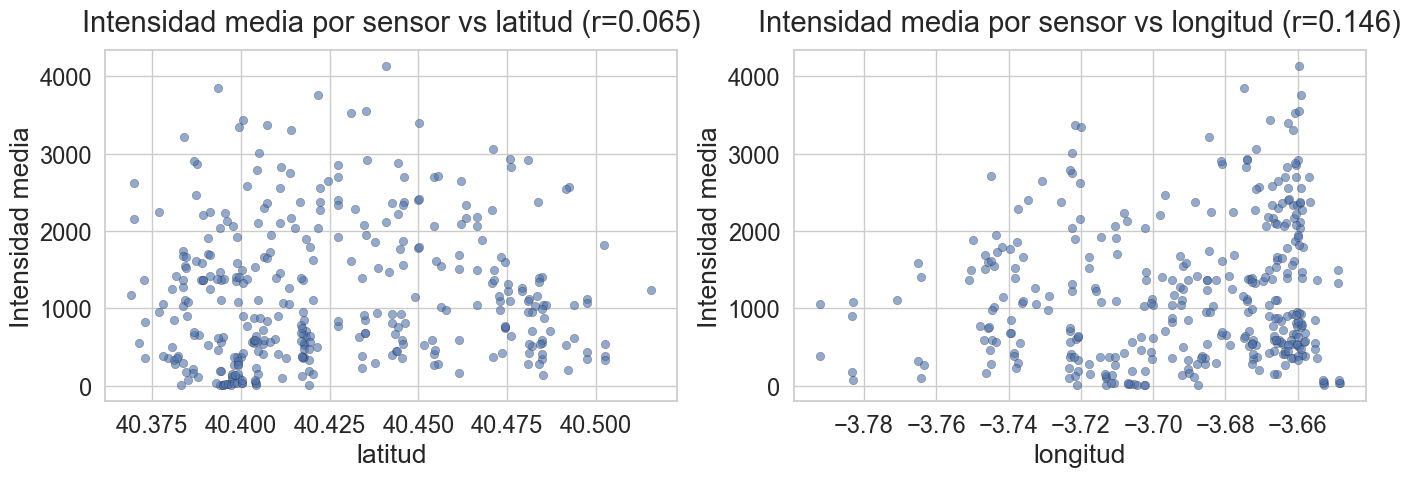

In [26]:
spatial_vars = ['latitud', 'longitud']

# Global correlation
global_corr_spatial = df[spatial_vars + ['intensidad']].corr()['intensidad'].drop('intensidad')
print('Correlación de Pearson global con intensidad:')
print(global_corr_spatial.round(4))

# Sensor-level correlation (latitud/longitud constant per sensor — within-sensor undefined)
sensor_corr = sensor_stats[['latitud', 'longitud', 'mean_intensidad']].corr()['mean_intensidad'].drop('mean_intensidad')
print(f'\nCorrelación a nivel de sensor (intensidad media por sensor vs coordenadas):')
print(sensor_corr.round(4))

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, var in enumerate(spatial_vars):
        axes[i].scatter(sensor_stats[var], sensor_stats['mean_intensidad'], alpha=0.6, edgecolors='k', linewidth=0.3)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Intensidad media')
        r = sensor_corr[var]
        axes[i].set_title(f'Intensidad media por sensor vs {var} (r={r:.3f})')
    plt.tight_layout()
    plt.show()

## 9. Pairplot — top correlated continuous features

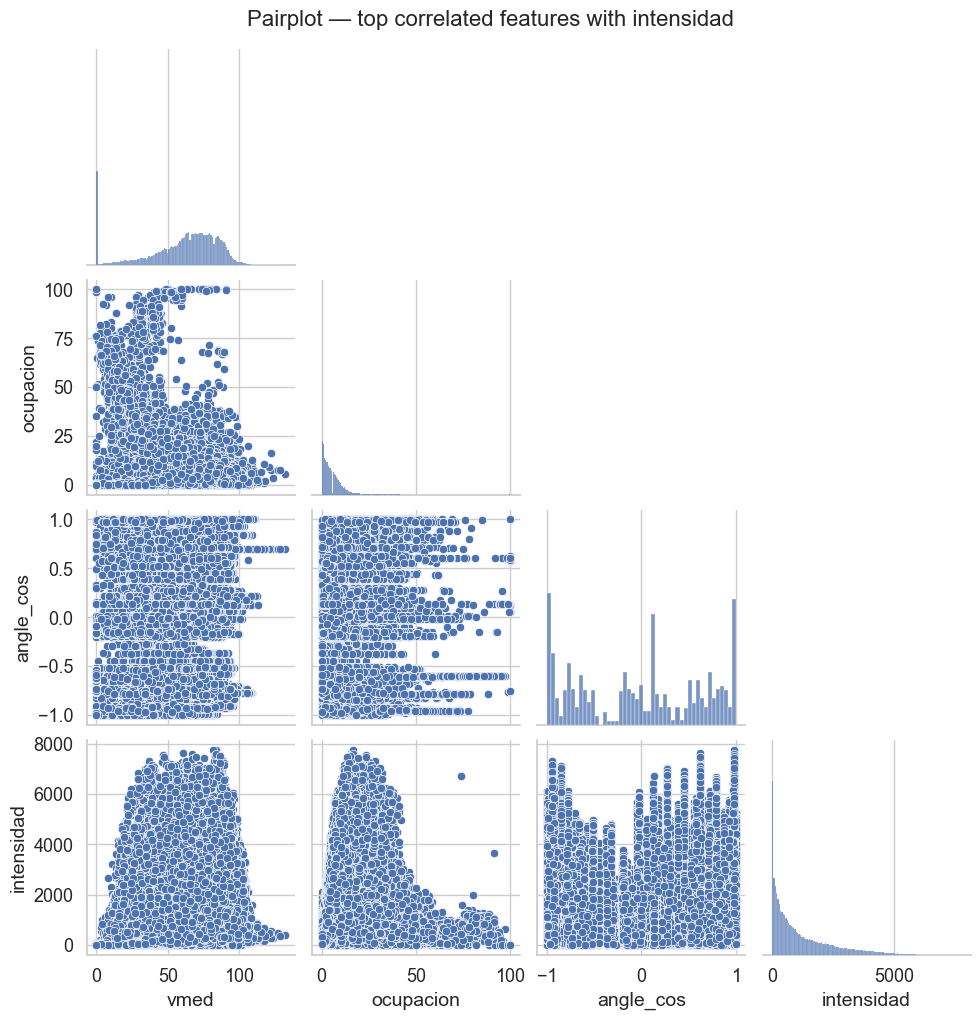

: 

In [ ]:
top_features = target_corr.head(3).index.tolist() + ['intensidad']
sns.pairplot(df_sample[top_features], corner=True)
plt.suptitle('Pairplot — top correlated features with intensidad', y=1.02)
plt.show()

## 10. Conclusiones

Tras el análisis exploratorio realizado sobre el dataset unificado de tráfico y meteorología (9.729.720 registros, 33 columnas, sensores M30, periodo 2023-2025), se extraen las siguientes conclusiones:

### Calidad de los datos

- El dataset **no contiene valores nulos**, gracias al preprocesamiento previo realizado en los notebooks anteriores (imputación, filtrado de errores).
- Se identificaron **columnas de metadatos y control de calidad** (`periodo_integracion`, `n_error_*`, `peso_loss`, `*_is_imputed`, etc.) que no deben emplearse como variables predictoras, ya que representan propiedades del proceso de medición y no del tráfico en sí.
- La columna `tipo_elem` es constante (`C30` — M30) al haber filtrado previamente el dataset a sensores interurbanos, por lo que carece de poder discriminante.

### Variable objetivo: `intensidad`

- **Media**: 1.222 veh/h, **mediana**: 759 veh/h. La diferencia indica un **sesgo positivo** confirmado por el coeficiente de asimetría (skewness = 1,44).
- La distribución presenta una **cola derecha pronunciada** (kurtosis = 1,76), con valores que alcanzan hasta ~19.600 veh/h.
- El **3,89% de los valores se clasifican como outliers** según el método IQR, lo que es esperable dado el rango natural de intensidades entre horas punta y horas valle.
- La transformación logarítmica (`log(1 + intensidad)`) produce una distribución más simétrica, lo que sugiere que podría ser beneficioso aplicar esta transformación para ciertos modelos predictivos.

### Variables continuas

| Variable | Observación |
|----------|-------------|
| `ocupacion` | Concentrada en valores bajos (media 5,9%, mediana 3,75%), con un 5,07% de outliers. Correlación moderada con la target (r = 0,34). |
| `vmed` | Velocidad media ~64 km/h, rango 0–171 km/h. Correlación moderada negativa o positiva dependiendo del régimen de tráfico (r = 0,32). |
| `temp` | Rango -4,3 °C a 40,3 °C (media 15,3 °C). Correlación baja con la target (r = 0,13), aunque puede capturar patrones estacionales. Sin outliers por IQR. |
| `prcp` | Altamente concentrada en 0 (la mayoría de horas no llueve), con un 7,76% de outliers. Correlación casi nula (r = 0,005). |
| `wspd` | Velocidad del viento media 11,6 km/h. Correlación muy baja (r = 0,04). |
| `latitud` | Rango 40,369–40,516 (desviación estándar 0,035). Sin outliers por IQR. Correlación baja con la target a nivel global (r = 0,035) y a nivel de sensor (r = 0,051). |
| `longitud` | Rango -3,792 a -3,648 (desviación estándar 0,033). Sin outliers por IQR. Correlación baja-moderada a nivel de sensor (r = 0,146), la más alta entre las variables espaciales. |

### Análisis de outliers — decisión por variable

La sección 5 identificó outliers mediante el método IQR (1,5 × IQR). A continuación se evalúa cada variable individualmente para decidir si procede eliminar, recortar o conservar estos valores:

| Variable | Outliers | % | Decisión | Justificación |
|----------|---------|---|----------|---------------|
| `intensidad` | 378.630 | 3,89% | **Conservar** | Son picos reales de hora punta (hasta ~19.600 veh/h). Eliminarlos sesgaría el modelo hacia la infrapredicción en los momentos de mayor demanda, que son precisamente los más relevantes para la gestión del tráfico. |
| `ocupacion` | 493.340 | 5,07% | **Conservar** | Representan eventos genuinos de congestión (ocupación alta). Siendo el predictor within-sensor más fuerte (mediana r = 0,79), eliminar estos valores supondría descartar la señal más informativa sobre saturación de la vía. |
| `vmed` | 382.752 | 3,93% | **Conservar** | Valores altos (hasta 171 km/h) son plausibles en flujo libre en la M30 (límite 90–100 km/h, pero las medias horarias pueden superarlo). Valores bajos cercanos a 0 con `intensidad > 0` representan congestión severa (stop-and-go), no errores de medición — los errores de sensor ya fueron filtrados en el preprocesamiento. |
| `prcp` | 755.001 | 7,76% | **Conservar** | El método IQR es inadecuado para precipitación: como Q1 = Q3 = 0 (no llueve la mayoría de las horas), *cualquier* valor de lluvia se marca como outlier. El máximo de 12,3 mm/h corresponde a lluvia intensa pero completamente real para Madrid. Estos episodios de lluvia son precisamente los eventos que el modelo necesita aprender. |
| `temp` | 0 | 0,00% | **Sin acción** | Rango de -4,3 °C a 40,3 °C, completamente normal para el clima de Madrid. |
| `wspd` | 171.288 | 1,76% | **Conservar** | El máximo de 46,4 km/h representa viento fuerte pero no extremo. La tasa de outliers es baja y corresponde a eventos meteorológicos reales. |
| `latitud` | 0 | 0,00% | **Sin acción** | Variable espacial fija por sensor. Sin outliers. |
| `longitud` | 0 | 0,00% | **Sin acción** | Variable espacial fija por sensor. Sin outliers. |

**Decisión global: no se eliminan outliers.** Las razones son:

1. **Los errores de medición ya fueron depurados** en la fase de preprocesamiento (notebook 2), mediante filtrado por flags de error, imputación controlada y validación de registros. Los valores que permanecen en el dataset han pasado controles de calidad.
2. **Todos los outliers detectados corresponden a fenómenos físicos reales** (hora punta, congestión, lluvia, viento fuerte), no a artefactos de medición.
3. **Los modelos previstos son robustos ante outliers**: tanto los modelos basados en árboles (XGBoost, LightGBM) como las redes neuronales no se ven distorsionados por valores extremos de la misma manera que la regresión lineal.
4. **Eliminar las colas de la distribución supondría perder los escenarios operativamente más relevantes** — la capacidad de predecir correctamente picos de tráfico, episodios de congestión y el impacto de condiciones meteorológicas adversas es precisamente el valor del modelo.
5. Las **variables espaciales** (`latitud`, `longitud`) no presentan outliers por ser coordenadas fijas de los sensores dentro del recorrido de la M30.

### Correlación global vs. within-sensor

El análisis de correlaciones **globales** (sobre todo el dataset) puede resultar engañoso cuando los datos provienen de múltiples sensores con diferentes niveles base de tráfico, debido a la **paradoja de Simpson**. Para aislar las relaciones que el modelo de forecasting realmente explotará (predicción por sensor individual), se realizó un análisis within-sensor mediante demeaning y correlaciones individuales por sensor.

Nota: `latitud` y `longitud` se excluyen de este análisis porque son constantes dentro de cada sensor (varianza cero tras demeaning), por lo que la correlación within-sensor no está definida. Su efecto se analiza en la sección de variables espaciales.

| Variable | r global | r within-sensor (demeaned) | Cambio de signo |
|----------|----------|----------------------------|-----------------|
| `ocupacion` | 0,34 | 0,41 | No |
| `vmed` | 0,32 | **-0,01** | **Sí** |
| `temp` | 0,13 | 0,18 | No |
| `forecast_temp` | 0,09 | 0,12 | No |
| `wspd` | 0,04 | 0,06 | No |
| `prcp` | 0,01 | 0,01 | No |
| `forecast_prec` | -0,002 | -0,003 | No |

Hallazgos principales:

- **`ocupacion` es el predictor continuo dominante**: la correlación global (r = 0,34) subestimaba enormemente su poder predictivo real. Dentro de cada sensor, la mediana de correlación con `intensidad` alcanza **r = 0,79**, lo que tiene sentido físico: la ocupación mide directamente el uso de la vía.
- **`vmed` presenta un cambio de signo** (paradoja de Simpson confirmada): la correlación global positiva (r = 0,32) era un artefacto entre-sensores (las vías de alta capacidad tienen simultáneamente mayor velocidad y mayor volumen). La correlación demeaned es prácticamente nula (r = -0,01), pero la distribución per-sensor es **bimodal** (std = 0,43, rango [-0,81, +0,94]): algunos sensores muestran fuerte correlación negativa (congestión: más coches → menor velocidad) y otros positiva. Esto implica que la relación intensidad-velocidad es **dependiente del sensor** y un coeficiente global lineal carece de sentido.
- **`temp`** muestra una correlación ligeramente más fuerte within-sensor (mediana r = 0,21) y consistente entre sensores (std = 0,06), confirmando un efecto estacional/térmico modesto pero real.
- **`prcp` y `wspd`** permanecen con efecto negligible en ambas perspectivas.

### Variables categóricas

El análisis mediante **eta-squared (η²)** revela que:

| Variable | η² | Interpretación |
|----------|-----|----------------|
| `hora_dia` | 0,2296 | **Efecto grande**. La hora del día es con diferencia el factor más determinante de la intensidad de tráfico. |
| `distrito` | 0,0524 | **Efecto moderado**. Segunda variable categórica más informativa, superando a `dia_semana`. El distrito administrativo donde se ubica el sensor captura diferencias estructurales relevantes en niveles de tráfico. |
| `dia_semana` | 0,0109 | Efecto pequeño pero significativo. Diferencias claras entre días laborables y fines de semana. |
| `mes` | 0,0059 | Efecto menor. Refleja estacionalidad (descenso en verano, picos en meses laborables). |
| `coco` | 0,0056 | Efecto menor. Las condiciones meteorológicas extremas tienen impacto marginal. |
| `cldc` | 0,0035 | Efecto muy pequeño. |
| `festivo` | 0,0027 | Efecto pequeño. Los festivos presentan intensidades significativamente menores. |
| `vispera_festivo` | 0,0001 | Efecto despreciable. |

### Variables espaciales: `latitud`, `longitud`, `distrito`

Los sensores se distribuyen a lo largo de la M30, cubriendo **14 distritos** administrativos de Madrid con un total de **351 sensores**. La distribución de sensores por distrito es desigual: el distrito 2 (Arganzuela) cuenta con 42 sensores, mientras que el distrito 16 (Hortaleza) solo tiene 8.

**Distrito como variable categórica:**

- Con un **η² = 0,0524**, `distrito` es la **segunda variable categórica más informativa** tras `hora_dia`, superando a `dia_semana` (η² = 0,011). Esto indica que la ubicación geográfica del sensor explica ~5,2% de la varianza en intensidad, lo que refleja diferencias estructurales en el tipo de vía y la demanda de tráfico por zona.
- La **intensidad media varía notablemente entre distritos**: el distrito 4 (Salamanca) presenta la media más alta (1.995,8 veh/h), mientras que el distrito 16 (Hortaleza) presenta la más baja (753,1 veh/h) — una relación de 2,6:1. Los distritos 15 (Ciudad Lineal, 1.583 veh/h) y 5 (Chamartín, 1.475 veh/h) también destacan por tráfico elevado.
- El análisis de perfiles horarios por distrito revela que, si bien todos los distritos siguen el **patrón bimodal** típico (picos en hora punta de mañana y tarde), la **amplitud del patrón varía considerablemente**: los distritos con mayor tráfico medio muestran picos más pronunciados, mientras que los de menor tráfico presentan curvas más planas.

**Coordenadas geográficas:**

- `latitud` y `longitud` son variables fijas por sensor (no varían en el tiempo), por lo que no aportan información within-sensor. Su valor predictivo reside en capturar la **componente entre-sensores**: la ubicación geográfica como proxy del tipo de vía y nivel base de tráfico.
- La correlación a nivel de sensor (media de intensidad por sensor vs. coordenadas) es **baja para latitud** (r = 0,051) y **baja-moderada para longitud** (r = 0,146). Esto indica que la longitud tiene una relación ligeramente más pronunciada con los niveles de tráfico, coherente con la disposición este-oeste de la M30 y las diferencias entre la zona sur-oeste (tramos más capacidad) y la zona este.
- Estas correlaciones lineales son modestas, lo que sugiere que la relación entre ubicación y tráfico es **no lineal** — modelos basados en árboles o con embeddings espaciales captarán mejor esta estructura.

### Patrones temporales

- **Hora del día**: patrón bimodal clásico de tráfico urbano con picos en horas punta (mañana y tarde) y valles durante la madrugada.
- **Día de la semana**: los días laborables (lunes a viernes) muestran intensidades notablemente superiores al fin de semana.
- **Interacción hora × día**: el heatmap evidencia que el patrón horario cambia sustancialmente entre días laborables (doble pico) y fines de semana (pico único, más suave y desplazado).

### Implicaciones para el modelado predictivo

1. **`hora_dia` es la variable más informativa** (η² = 0,23), seguida de `distrito` (η² = 0,052) como segunda variable categórica más relevante, y `ocupacion` (mediana r = 0,79 per-sensor) como predictor continuo dominante. El modelo predictivo debería priorizar estas variables.
2. **`distrito` aporta información estructural significativa** que no estaba siendo considerada en versiones anteriores del análisis. Con η² = 0,052, explica más varianza que `dia_semana` (η² = 0,011). Su inclusión como variable categórica o mediante embeddings debería mejorar la capacidad del modelo para distinguir niveles base de tráfico por zona.
3. Las correlaciones lineales globales bajas eran **engañosas**: el análisis within-sensor revela relaciones mucho más fuertes (especialmente `ocupacion`), lo que refuerza la necesidad de **modelos no lineales** (gradient boosting, redes neuronales) que capturen estas dinámicas por sensor.
4. **`vmed` requiere tratamiento no lineal o per-sensor**: su distribución bimodal de correlaciones (rango [-0,81, +0,94]) implica que un coeficiente global único carece de sentido. Modelos basados en árboles o con embeddings de sensor manejarán esto de forma natural.
5. **`latitud` y `longitud`** tienen correlaciones lineales modestas con la intensidad (r = 0,05 y r = 0,15 a nivel de sensor, respectivamente), pero su valor reside en permitir al modelo capturar **patrones espaciales no lineales**. Son complementarias a `distrito`: mientras que el distrito agrupa sensores en zonas discretas, las coordenadas aportan una representación continua de la ubicación que puede capturar gradientes espaciales más finos.
6. La **heterogeneidad entre sensores** en las correlaciones, combinada con las diferencias significativas entre distritos, justifica evaluar modelos que capturen diferencias por ubicación (e.g., embeddings de sensor/distrito, modelos individuales por sensor, o agrupación por tipo de vía).
7. Las **variables meteorológicas** (`prcp`, `wspd`, `coco`, `cldc`) tienen un efecto individual pequeño tanto a nivel global como within-sensor, pero podrían aportar valor en combinación con las temporales (e.g., lluvia en hora punta).
8. `vispera_festivo` tiene un efecto prácticamente nulo y podría excluirse del modelo sin pérdida de información.
9. Dada la asimetría de la variable objetivo, conviene evaluar si una **transformación logarítmica** de `intensidad` mejora el rendimiento de los modelos sensibles a la distribución de la target.